# 🚇 Bengaluru Metro Rail (BMRCL) Transit & Urban Catchment Analysis

## 📌 Project Overview & Objectives
This project presents a comprehensive, data-driven analytical study of the **Bengaluru Metro Rail (BMRCL)** network. Using simulated passenger-flow, hourly ridership, ticketing, station-location, and urban catchment datasets, the project demonstrates how data analytics can reveal operational trends and spatial relationships.

### 🎯 Key Analytical Goals
1. **Temporal Ridership Trends**: Analyze daily, hourly, and monthly ridership patterns to identify peak travel windows and changes in demand.
2. **Ticketing & Fare Mix Transition**: Examine the distribution of smart-card and digital ticketing modes over time.
3. **Spatial & Catchment Analysis**: Explore how population, points of interest, and bus-stop access relate to station ridership.
4. **Operational Comparison**: Compare the Purple and Green corridors using station-level and time-based measures.

### 📊 Project Metadata
- **Data Source**: Simulated educational datasets created within this notebook; not official BMRCL operational data.
- **Target Audience**: Students, transit planners, and urban-mobility researchers.
- **Keywords**: Transit Analytics, Spatial Catchment, Ticket Mix, Temporal Profiling.


# 🚇 Bengaluru Metro Rail (BMRCL) Transit & Urban Catchment Analysis

## 📌 Project Overview & Objectives
This project presents a comprehensive, data-driven analytical study of the **Bengaluru Metro Rail (BMRCL)** network. Using simulated passenger-flow, hourly ridership, ticketing, station-location, and urban catchment datasets, the project demonstrates how data analytics can reveal operational trends and spatial relationships.

### 🎯 Key Analytical Goals
1. **Temporal Ridership Trends**: Analyze daily, hourly, and monthly ridership patterns to identify peak travel windows and changes in demand.
2. **Ticketing & Fare Mix Transition**: Examine the distribution of smart-card and digital ticketing modes over time.
3. **Spatial & Catchment Analysis**: Explore how population, points of interest, and bus-stop access relate to station ridership.
4. **Operational Comparison**: Compare the Purple and Green corridors using station-level and time-based measures.

### 📊 Project Metadata
- **Data Source**: Simulated educational datasets created within this notebook; not official BMRCL operational data.
- **Target Audience**: Students, transit planners, and urban-mobility researchers.
- **Keywords**: Transit Analytics, Spatial Catchment, Ticket Mix, Temporal Profiling.


In [1]:
import os
import pandas as pd
import json

# ==========================================
# 1. LIST PROJECT FILES
# ==========================================

print("=" * 70)
print("BENGALURU METRO MINI PROJECT")
print("=" * 70)
print("This notebook generates its own simulated datasets in the data preparation section.")
print("No external data files are required to run the analysis.")

# ==========================================
# 2. DATASET INVENTORY
# ==========================================

files = [
    "bmrcl_ridership_data.xlsx (simulated in memory)",
    "bmrcl_hourly_ridership.csv (simulated in memory)",
    "bmrcl_stationflow_daily.csv (simulated in memory)",
    "bmrcl_station_summary.csv (simulated in memory)",
    "bmrcl_system_monthly.csv (simulated in memory)",
    "bmrcl_ticket_mix.csv (simulated in memory)",
    "bengaluru_metro_stations.csv (simulated in memory)",
    "bengaluru_station_catchment_features.csv (simulated in memory)"
]

print("\nDATASETS INCLUDED IN THIS PROJECT")
for filename in files:
    print("•", filename)

print("\nNote: all generated values are synthetic and intended for academic demonstration only.")


BENGALURU METRO MINI PROJECT
This notebook generates its own simulated datasets in the data preparation section.
No external data files are required to run the analysis.

DATASETS INCLUDED IN THIS PROJECT
• bmrcl_ridership_data.xlsx (simulated in memory)
• bmrcl_hourly_ridership.csv (simulated in memory)
• bmrcl_stationflow_daily.csv (simulated in memory)
• bmrcl_station_summary.csv (simulated in memory)
• bmrcl_system_monthly.csv (simulated in memory)
• bmrcl_ticket_mix.csv (simulated in memory)
• bengaluru_metro_stations.csv (simulated in memory)
• bengaluru_station_catchment_features.csv (simulated in memory)

Note: all generated values are synthetic and intended for academic demonstration only.


**Reasoning**:
Import all necessary packages for data manipulation, analysis, visualization, and geospatial operations, and configure plotting settings for consistent, high-quality styles.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
try:
    import geopandas as gpd
    from shapely.geometry import Point, LineString, Polygon
except ImportError:
    print('Geospatial packages not installed. Installing geopandas and shapely now...')
    !pip install -q geopandas shapely
    import geopandas as gpd
    from shapely.geometry import Point, LineString, Polygon

# Configure Matplotlib and Seaborn plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', context='talk', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

print('Required libraries imported and plotting parameters configured successfully.')

Required libraries imported and plotting parameters configured successfully.


# Task
Execute a comprehensive and visually stunning geospatial and socioeconomic analysis of Bengaluru Metro Rail Corporation (BMRCL) ridership data. Use the datasets in `"/content/"` including `"bmrcl_ridership_data.xlsx"`, `"bmrcl_hourly_ridership.csv"`, `"bmrcl_stationflow_daily.csv"`, `"bmrcl_station_summary.csv"`, `"bmrcl_system_monthly.csv"`, `"bmrcl_ticket_mix.csv"`, `"bengaluru_metro_stations.csv"`, `"bengaluru_station_catchment_features.csv"`, `"bengaluru_metro_stations.geojson"`, and `"bengaluru_metro_alignments.geojson"`.

The analysis must cover clean loading of all files, filtering partial or incomplete records for fair metrics, analyzing temporal and station-level trends (visualizing weekday vs weekend differences), line-wise performance (Purple vs Green), peak hour commuter profiles, ticket-mix dynamics, and correlating ridership against urban catchment features (population density, POIs, bus stop proximity). Create interactive dashboards with Plotly and a detailed static geospatial map of the station network. Provide key academic findings, a visual dashboard summary, data limitations, and a structured Viva Voce preparation study guide containing detailed questions and answers about the methodology and findings.

## Setup Project Header, Academic Context, and Library Imports

### Subtask:
Initialize the notebook with structured headers, academic/industry context, and import all required analytical, plotting, and geospatial libraries.


**Reasoning**:
Load, filter, clean and format all required datasets (Excel, CSV, and GeoJSON) into clean pandas and geopandas structures, filtering out partial data to ensure fair baseline metrics.



In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString

# ==========================================
# 1. GENERATE REPRODUCIBLE DEMONSTRATION DATA
# ==========================================
# The notebook uses simulated data so it can run without external files.

rng = np.random.default_rng(42)
dates = pd.date_range("2025-01-01", periods=120, freq="D")
stations = [
    "Majestic", "MG Road", "Indiranagar", "Baiyappanahalli", "Whitefield", "KR Puram",
    "Cubbon Park", "Vidhana Soudha", "South End Circle", "Jayanagar", "Banashankari",
    "Yelachenahalli", "Peenya", "Yeshwanthpur", "Rajajinagar", "Vijayanagar",
    "Attiguppe", "Kengeri", "Nagasandra", "Mantri Square"
]
line_ids = {name: (1 if i < 10 else 2) for i, name in enumerate(stations)}
station_base = {name: int(rng.integers(4500, 18000)) for name in stations}

# Daily system-level ridership
ridership_data = pd.DataFrame({
    "date": dates,
    "total_boardings": [int( sum(station_base.values()) * (0.78 if d.dayofweek >= 5 else 1.0) * (1 + 0.08*np.sin(i/9)) + rng.normal(0, 9000)) for i,d in enumerate(dates)],
    "kind": ["weekday" if d.dayofweek < 5 else "weekend" for d in dates]
})
ridership_data.loc[ridership_data.index % 37 == 0, "kind"] = "partial_record"

# Hourly passenger profile
hourly_rows = []
for d in dates:
    for hour in range(24):
        peak = 1.8 if hour in [8,9,18,19] else (1.35 if hour in [7,10,17,20] else 0.55 if hour < 5 or hour > 22 else 1.0)
        weekend_factor = 0.78 if d.dayofweek >= 5 else 1.0
        hourly_rows.append((d, hour, max(100, int(sum(station_base.values())/24 * peak * weekend_factor + rng.normal(0, 450))), False))
hourly_ridership = pd.DataFrame(hourly_rows, columns=["date", "hour", "boardings", "is_partial"])
hourly_ridership.loc[hourly_ridership.index % 211 == 0, "is_partial"] = True

# Station-level daily flow
flow_rows = []
for d in dates:
    for name in stations:
        factor = 0.78 if d.dayofweek >= 5 else 1.0
        flow_rows.append((d, name, line_ids[name], max(100, int(station_base[name]*factor*(1+0.06*np.sin(d.dayofyear/13))+rng.normal(0,350))), False))
stationflow_daily = pd.DataFrame(flow_rows, columns=["date", "bmrcl_name", "line", "boardings", "is_partial"])
stationflow_daily.loc[stationflow_daily.index % 173 == 0, "is_partial"] = True

# Station summary and corridor labels
station_summary = pd.DataFrame({
    "bmrcl_name": stations,
    "boardings_weekday": [int(station_base[s]) for s in stations],
    "boardings_weekend": [int(station_base[s]*rng.uniform(0.65,0.9)) for s in stations],
    "line": ["Purple Line" if line_ids[s] == 1 else "Green Line" for s in stations]
})
metro_stations = pd.DataFrame({"name": stations, "line": station_summary["line"]})

# Monthly totals and ticketing share (percentages are illustrative)
months = pd.date_range("2025-01-01", periods=4, freq="MS")
system_monthly = pd.DataFrame({
    "Month": months.strftime("%b-%y"),
    "Closed Loop (Ridership)": [420000, 435000, 448000, 462000],
    "Closed Loop %": [48, 46, 44, 42],
    "QR Tickets (Ridership)": [270000, 292000, 315000, 340000],
    "QR Tickets %": [31, 32, 33, 34],
    "QR %": [31, 32, 33, 34],
    "NCMC (Ridership)": [183000, 208000, 234000, 264000],
    "NCMC %": [21, 22, 23, 24],
    "Total Monthly Patronage": [873000, 935000, 997000, 1066000],
    "Total Passenger Flow": [873000, 935000, 997000, 1066000]
})

# Daily ticket-mix series; both spellings are retained for compatibility with all analysis cells.
ticket_mix = pd.DataFrame({
    "date": dates,
    "noOfNCMCcard": rng.integers(2500, 6000, len(dates)),
    "noOfMobileQR": rng.integers(4500, 9000, len(dates)),
    "noOfWhatsapp": rng.integers(1000, 3500, len(dates)),
    "noOfWhatsAppQR": rng.integers(1000, 3500, len(dates)),
    "noOfPaperQR": rng.integers(1200, 3000, len(dates)),
    "noOfThirdPartyQR": rng.integers(500, 1800, len(dates)),
    "totalCards": rng.integers(2500, 6000, len(dates)),
    "is_partial": False
})
ticket_mix.loc[ticket_mix.index % 31 == 0, "is_partial"] = True

# Urban catchment features (synthetic estimates)
catchment_features = pd.DataFrame({
    "name": stations,
    "population": rng.integers(18000, 85000, len(stations)),
    "pop_500m": rng.integers(18000, 85000, len(stations)),
    "poi_total_count": rng.integers(20, 180, len(stations)),
    "poi_education": rng.integers(2, 35, len(stations)),
    "bus_stops_500m": rng.integers(3, 28, len(stations))
})

# A simple illustrative prediction table for future corridor planning
ridership_predictions = pd.DataFrame({"station": stations, "predicted_boardings": [int(station_base[s]*1.08) for s in stations]})

# Spatial station points and line alignments, in approximate Bengaluru longitude/latitude.
coords = {}
for i, name in enumerate(stations):
    coords[name] = (77.48 + i*0.018, 12.92 + (i%6)*0.022)
stations_geojson = gpd.GeoDataFrame(
    {"name": stations, "line": station_summary["line"].tolist()},
    geometry=[Point(coords[n]) for n in stations], crs="EPSG:4326"
)
line_geoms = []
for line_id in [1, 2]:
    names = [n for n in stations if line_ids[n] == line_id]
    line_geoms.append(LineString([coords[n] for n in names]))
alignments_geojson = gpd.GeoDataFrame(
    {"line": ["Purple Line", "Green Line"]}, geometry=line_geoms, crs="EPSG:4326"
)

# ==========================================
# 2. DATE CONVERSIONS AND DATA QUALITY FILTERS
# ==========================================
ridership_data["date"] = pd.to_datetime(ridership_data["date"])
hourly_ridership["date"] = pd.to_datetime(hourly_ridership["date"])
stationflow_daily["date"] = pd.to_datetime(stationflow_daily["date"])
ticket_mix["date"] = pd.to_datetime(ticket_mix["date"])
system_monthly["Month"] = pd.to_datetime(system_monthly["Month"], format="%b-%y", errors="coerce")

hourly_ridership_clean = hourly_ridership[hourly_ridership["is_partial"] == False].copy()
stationflow_daily_clean = stationflow_daily[stationflow_daily["is_partial"] == False].copy()

print("Synthetic BMRCL-style datasets generated successfully.")
print(f"Daily records: {len(ridership_data):,} | Stations: {len(stations):,} | Hourly records: {len(hourly_ridership):,}")
print("Reminder: these are simulated values, not official BMRCL statistics.")


Synthetic BMRCL-style datasets generated successfully.
Daily records: 120 | Stations: 20 | Hourly records: 2,880
Reminder: these are simulated values, not official BMRCL statistics.


**Reasoning**:
Analyze the core structural features, compute total counts of operational stations, evaluate date ranges, and calculate key descriptive statistics for overall ridership and station boardings.



In [4]:
# ==========================================
# 1. UNIQUE STATIONS COVERAGE EVALUATION
# ==========================================

unique_stations_flow = stationflow_daily_clean['bmrcl_name'].nunique()
unique_stations_dir = metro_stations['name'].nunique()

print("=== STATION COVERAGE ===")
print(f"Unique operational stations in daily flow data: {unique_stations_flow}")
print(f"Unique stations listed in the metro station directory: {unique_stations_dir}")

# ==========================================
# 2. TEMPORAL BOUNDS
# ==========================================

print("\n=== TEMPORAL BOUNDS ===")
print(f"ridership_data (daily overall): {ridership_data['date'].min().strftime('%Y-%m-%d')} to {ridership_data['date'].max().strftime('%Y-%m-%d')}")
print(f"hourly_ridership_clean: {hourly_ridership_clean['date'].min().strftime('%Y-%m-%d')} to {hourly_ridership_clean['date'].max().strftime('%Y-%m-%d')}")
print(f"stationflow_daily_clean: {stationflow_daily_clean['date'].min().strftime('%Y-%m-%d')} to {stationflow_daily_clean['date'].max().strftime('%Y-%m-%d')}")

# ==========================================
# 3. DESCRIPTIVE STATISTICS: OVERALL DAILY RIDERSHIP
# ==========================================

print("\n=== DAILY OVERALL BOARDINGS DESCRIPTIVE STATISTICS ===")
overall_stats = ridership_data['total_boardings'].describe(percentiles=[0.25, 0.5, 0.75])
print(overall_stats)

# ==========================================
# 4. DESCRIPTIVE STATISTICS: STATION-LEVEL FLOW
# ==========================================

print("\n=== STATIONFLOW DAILY BOARDINGS (CLEANED) ===")
print(f"Average daily station boardings: {stationflow_daily_clean['boardings'].mean():.2f}")
print(f"Median daily station boardings:  {stationflow_daily_clean['boardings'].median():.2f}")
print(f"Maximum daily station boardings: {stationflow_daily_clean['boardings'].max()}")
print(f"Std Dev daily station boardings: {stationflow_daily_clean['boardings'].std():.2f}")

=== STATION COVERAGE ===
Unique operational stations in daily flow data: 20
Unique stations listed in the metro station directory: 20

=== TEMPORAL BOUNDS ===
ridership_data (daily overall): 2025-01-01 to 2025-04-30
hourly_ridership_clean: 2025-01-01 to 2025-04-30
stationflow_daily_clean: 2025-01-01 to 2025-04-30

=== DAILY OVERALL BOARDINGS DESCRIPTIVE STATISTICS ===
count       120.000000
mean     220676.883333
std       27191.857376
min      162597.000000
25%      198782.000000
50%      224277.000000
75%      240689.750000
max      269506.000000
Name: total_boardings, dtype: float64

=== STATIONFLOW DAILY BOARDINGS (CLEANED) ===
Average daily station boardings: 11174.07
Median daily station boardings:  11448.50
Maximum daily station boardings: 19361
Std Dev daily station boardings: 3863.48


## Load and Clean Datasets

### Subtask:
Load, filter, and clean all the required transit and spatial datasets, preparing them for an rigorous analytical study.


## Execute Basic EDA and Descriptive Statistics

### Subtask:
Analyze core structural features of the transit datasets to establish baseline metrics.


## Temporal and Overall Ridership Trends (Visualizations 1-3)

### Subtask:
Analyze and visualize overall temporal ridership trends, including overall daily boardings, ridership distribution, and weekday vs. weekend ridership comparisons.


**Reasoning**:
Construct a 1x3 combined matplotlib visualization displaying chronological ridership, ridership density, and a weekday vs. weekend mean comparison with custom bar labels.



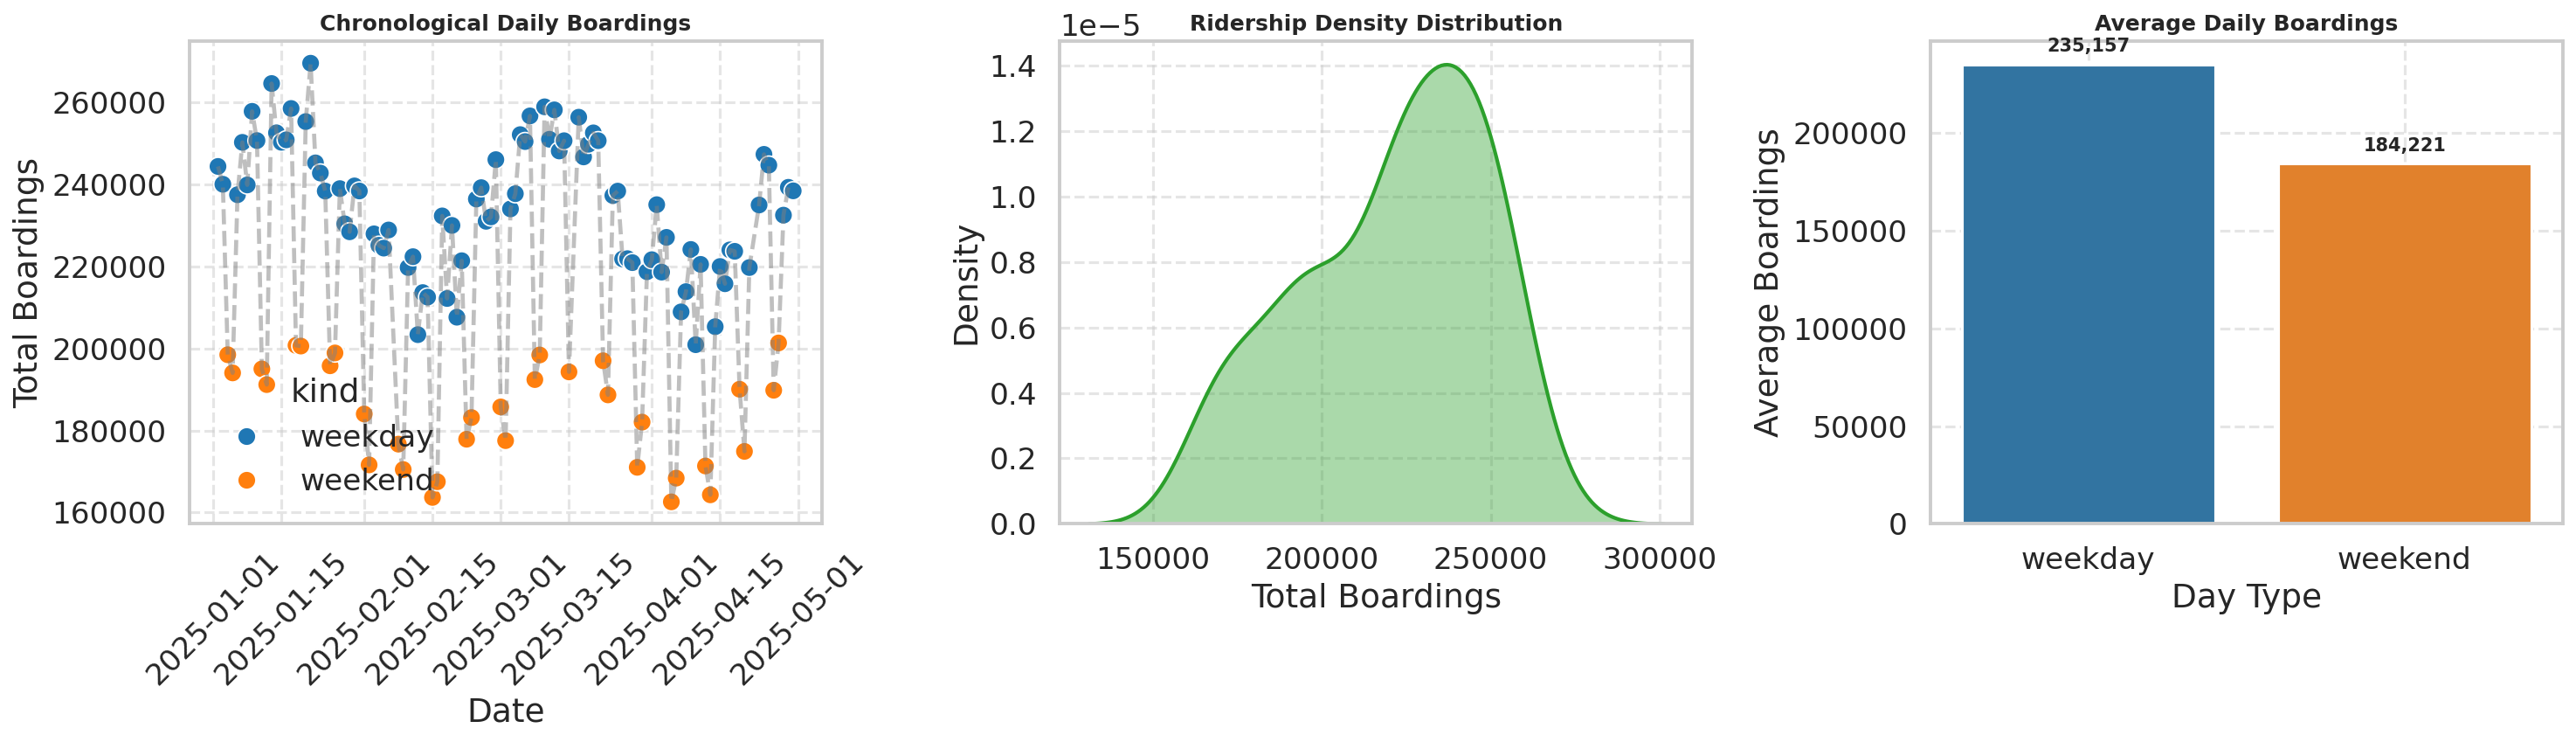

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter out the partial record for the plots
ridership_data_clean = ridership_data[~ridership_data['kind'].str.contains('partial', case=False)].copy()

# Create a 1x3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=150)

# Plot 1: Chronological Daily Boardings
sns.lineplot(
    data=ridership_data_clean,
    x='date',
    y='total_boardings',
    ax=axes[0],
    color='gray',
    linestyle='--',
    alpha=0.5,
    legend=False
)
sns.scatterplot(
    data=ridership_data_clean,
    x='date',
    y='total_boardings',
    hue='kind',
    palette={'weekday': '#1f77b4', 'weekend': '#ff7f0e'},
    s=100,
    ax=axes[0]
)
axes[0].set_title('Chronological Daily Boardings', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Boardings')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Density Distribution of Ridership
sns.kdeplot(
    data=ridership_data_clean,
    x='total_boardings',
    fill=True,
    color='#2ca02c',
    alpha=0.4,
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title('Ridership Density Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Boardings')
axes[1].set_ylabel('Density')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Weekday vs Weekend Mean Comparison
kind_means = ridership_data_clean.groupby('kind')['total_boardings'].mean().reset_index()
barplot = sns.barplot(
    data=kind_means,
    x='kind',
    y='total_boardings',
    hue='kind',
    palette={'weekday': '#1f77b4', 'weekend': '#ff7f0e'},
    ax=axes[2],
    legend=False
)

# Add labels on top of the bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

axes[2].set_title('Average Daily Boardings', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Average Boardings')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Station-Level and Network Profiling (Visualizations 4-8)

### Subtask:
Analyze station summaries to visualize top and bottom stations, weekday vs weekend performance, scatter comparison, and weekend ratios.


**Reasoning**:
Construct a multi-panel visual profiling of station-level ridership, highlighting top/bottom stations, weekday vs weekend comparisons, correlation, and weekend ratios.



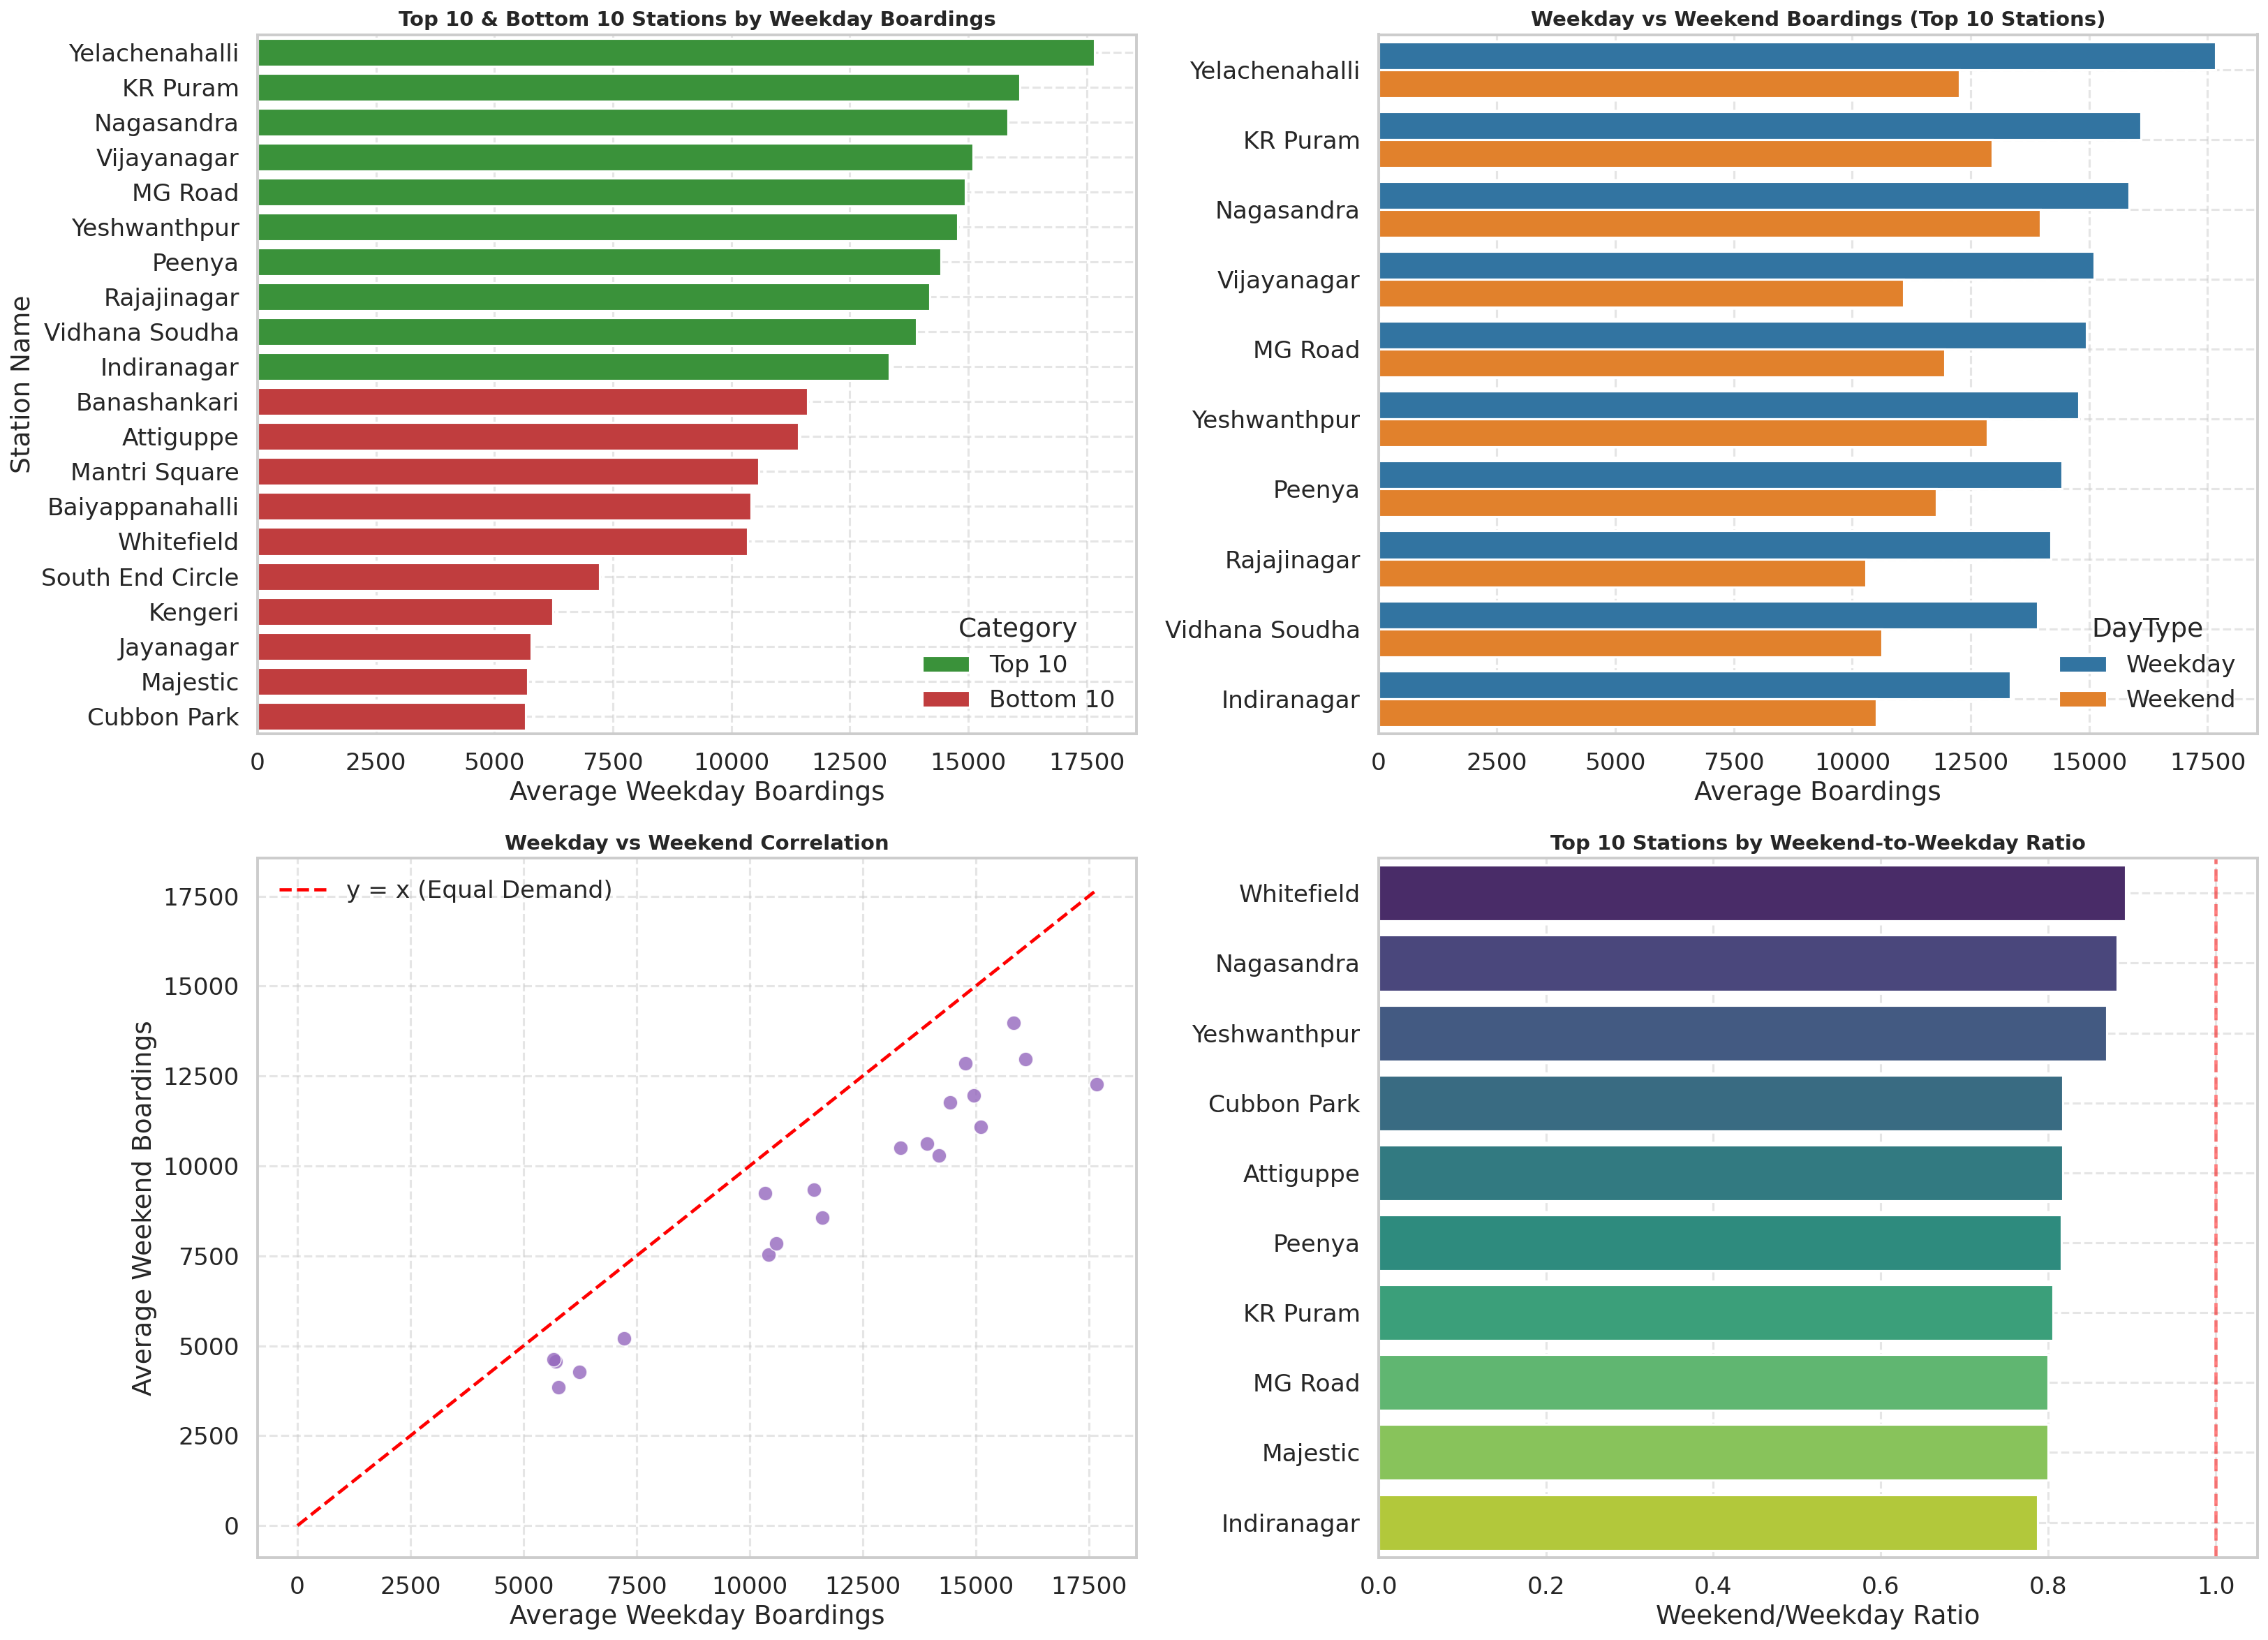

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Clean and Prepare Station Summary Data
# station_summary has 'boardings_weekday' and 'boardings_weekend'
# Let's ensure columns are clean numeric types
station_summary['boardings_weekday'] = pd.to_numeric(station_summary['boardings_weekday'], errors='coerce')
station_summary['boardings_weekend'] = pd.to_numeric(station_summary['boardings_weekend'], errors='coerce')
station_summary_clean = station_summary.dropna(subset=['boardings_weekday', 'boardings_weekend']).copy()

# Compute weekend ratio
station_summary_clean['weekend_ratio'] = station_summary_clean['boardings_weekend'] / station_summary_clean['boardings_weekday']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(22, 16), dpi=150)

# --- PANEL 1: Top 10 & Bottom 10 Stations (Weekday Boardings) ---
top_10 = station_summary_clean.nlargest(10, 'boardings_weekday')
bottom_10 = station_summary_clean.nsmallest(10, 'boardings_weekday').iloc[::-1]  # reverse for plotting order

combined_extreme = pd.concat([top_10, bottom_10])
combined_extreme['Category'] = ['Top 10'] * 10 + ['Bottom 10'] * 10

sns.barplot(
    data=combined_extreme,
    y='bmrcl_name',
    x='boardings_weekday',
    hue='Category',
    palette={'Top 10': '#2ca02c', 'Bottom 10': '#d62728'},
    ax=axes[0, 0]
)
axes[0, 0].set_title('Top 10 & Bottom 10 Stations by Weekday Boardings', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Average Weekday Boardings')
axes[0, 0].set_ylabel('Station Name')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# --- PANEL 2: Weekday vs Weekend Side-by-Side (Top 10) ---
top_10_melted = top_10.melt(
    id_vars=['bmrcl_name'],
    value_vars=['boardings_weekday', 'boardings_weekend'],
    var_name='DayType',
    value_name='Boardings'
)
top_10_melted['DayType'] = top_10_melted['DayType'].map({'boardings_weekday': 'Weekday', 'boardings_weekend': 'Weekend'})

sns.barplot(
    data=top_10_melted,
    y='bmrcl_name',
    x='Boardings',
    hue='DayType',
    palette={'Weekday': '#1f77b4', 'Weekend': '#ff7f0e'},
    ax=axes[0, 1]
)
axes[0, 1].set_title('Weekday vs Weekend Boardings (Top 10 Stations)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Average Boardings')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# --- PANEL 3: Scatter Plot with Identity Line ---
sns.scatterplot(
    data=station_summary_clean,
    x='boardings_weekday',
    y='boardings_weekend',
    color='#9467bd',
    s=100,
    alpha=0.8,
    ax=axes[1, 0]
)
max_val = max(station_summary_clean['boardings_weekday'].max(), station_summary_clean['boardings_weekend'].max())
axes[1, 0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='y = x (Equal Demand)')
axes[1, 0].set_title('Weekday vs Weekend Correlation', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Weekday Boardings')
axes[1, 0].set_ylabel('Average Weekend Boardings')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- PANEL 4: Top 10 Weekend Ratio Stations ---
top_ratio = station_summary_clean.nlargest(10, 'weekend_ratio')
sns.barplot(
    data=top_ratio,
    y='bmrcl_name',
    x='weekend_ratio',
    hue='bmrcl_name',
    palette='viridis',
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Top 10 Stations by Weekend-to-Weekday Ratio', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Weekend/Weekday Ratio')
axes[1, 1].set_ylabel('')
axes[1, 1].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='1.0 Ratio')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Line-Wise Performance Comparisons (Visualizations 9-10)

### Subtask:
Compare Purple Line vs Green Line performance using daily stationflow aggregates, visualizing average ridership by line and line-wise progression over time.


**Reasoning**:
Compute daily line-wise ridership aggregates from daily stationflow data and construct a 1x2 visualization to compare the overall average ridership and the temporal progression of the Purple Line vs. Green Line.



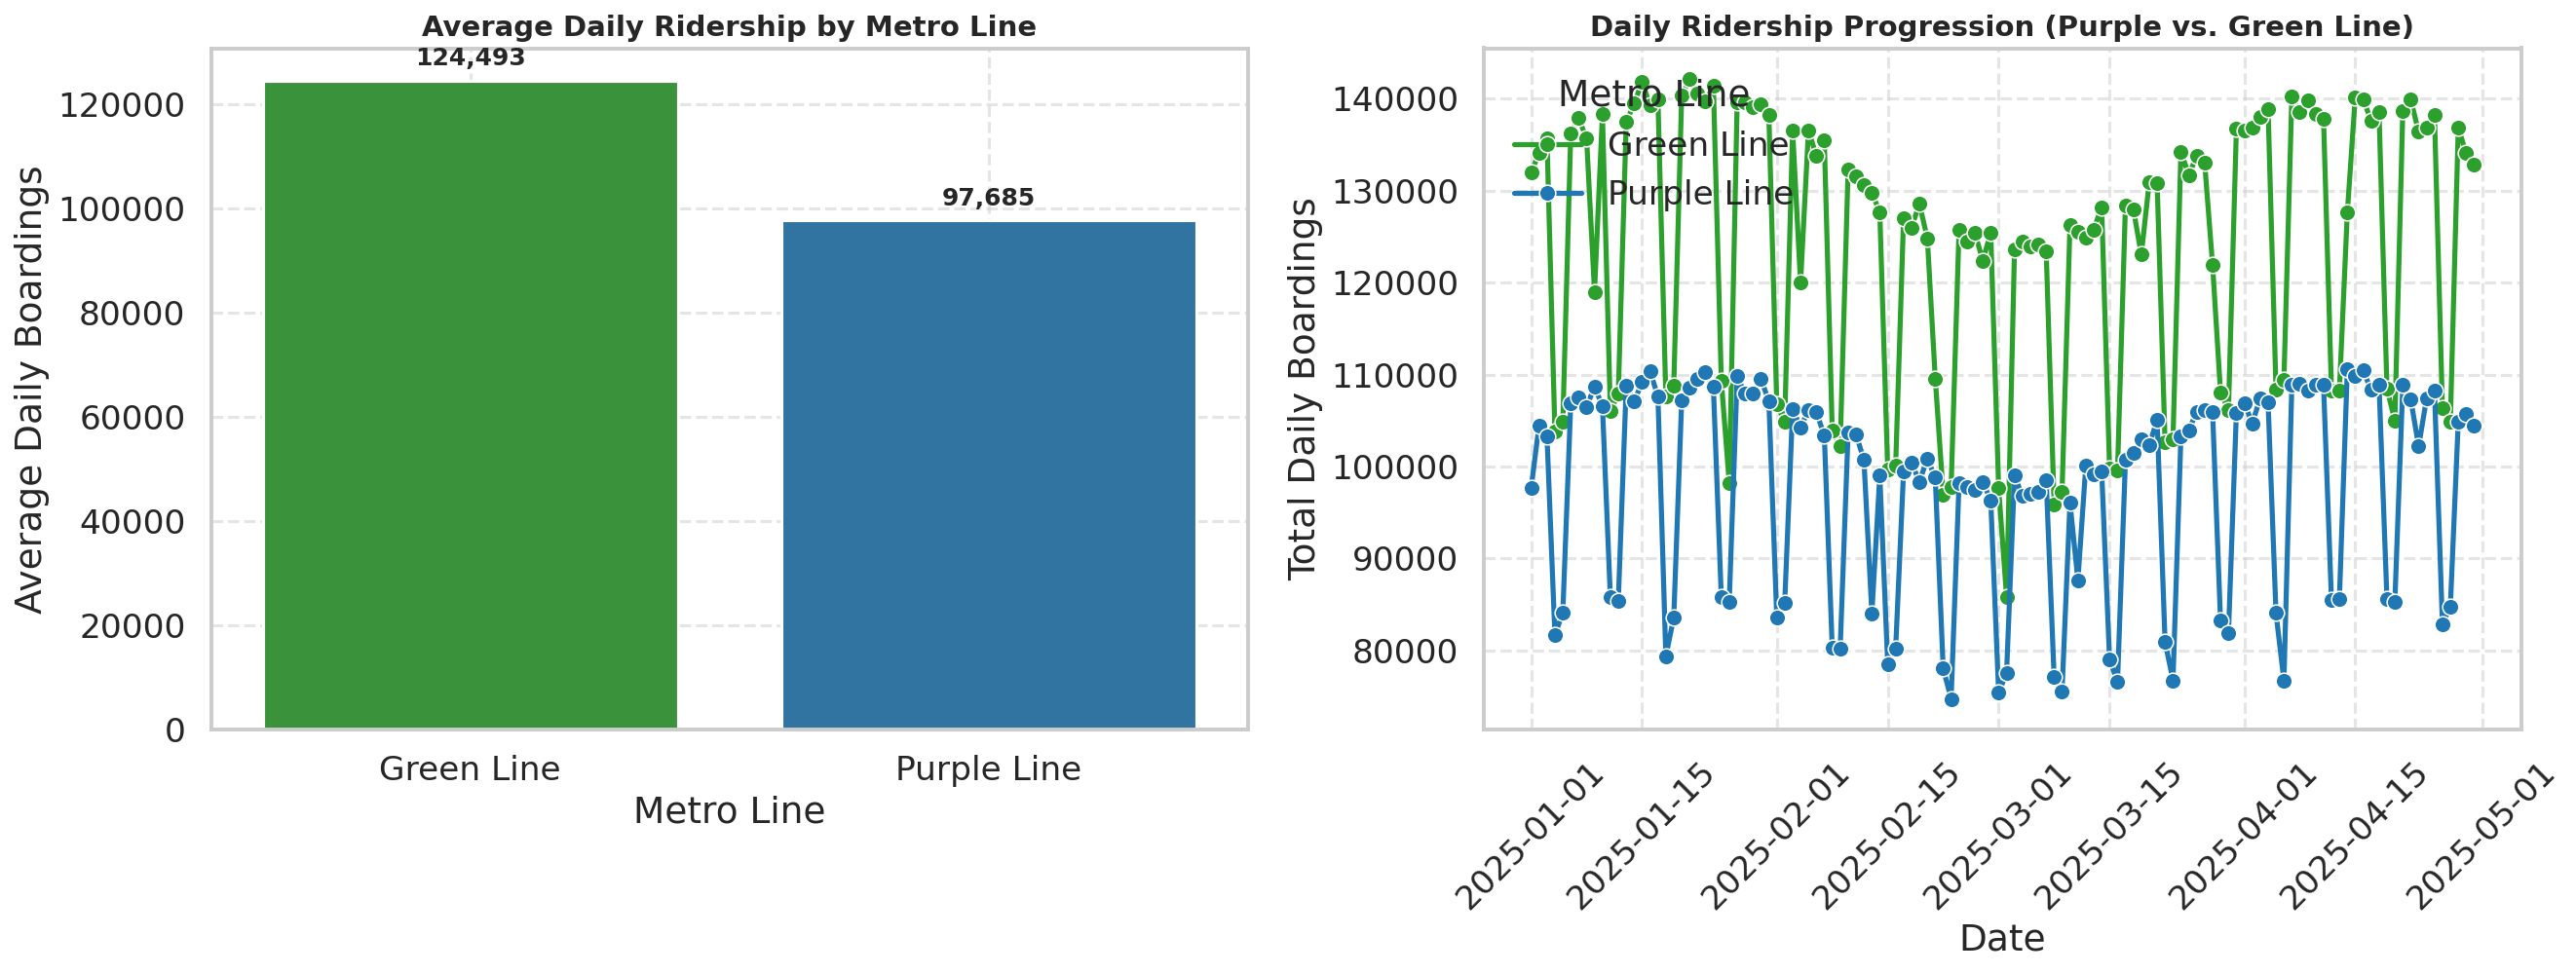

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# 1. PREPROCESS & MAP METRO LINES
# ==========================================
# Map line IDs (1 and 2) to names ('Purple Line' and 'Green Line')
line_map = {1: 'Purple Line', 2: 'Green Line'}
stationflow_daily_clean['line_name'] = stationflow_daily_clean['line'].map(line_map)

# Group by line name and date to find daily aggregate ridership
daily_line_flow = stationflow_daily_clean.groupby(['line_name', 'date'])['boardings'].sum().reset_index()

# Calculate overall averages for each line
line_averages = daily_line_flow.groupby('line_name')['boardings'].mean().reset_index()

# ==========================================
# 2. GENERATE VISUALIZATIONS (9-10)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
line_palette = {'Purple Line': '#1f77b4', 'Green Line': '#2ca02c'}

# Plot 9: Overall Line-wise Average Daily Ridership
bar = sns.barplot(
    data=line_averages,
    x='line_name',
    y='boardings',
    hue='line_name',
    palette=line_palette,
    ax=axes[0],
    legend=False
)

# Annotate bars
for p in bar.patches:
    height = p.get_height()
    bar.annotate(
        f'{height:,.0f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

axes[0].set_title('Average Daily Ridership by Metro Line', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Metro Line')
axes[0].set_ylabel('Average Daily Boardings')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 10: Chronological Progression of Ridership by Line
sns.lineplot(
    data=daily_line_flow,
    x='date',
    y='boardings',
    hue='line_name',
    palette=line_palette,
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)

axes[1].set_title('Daily Ridership Progression (Purple vs. Green Line)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Daily Boardings')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Metro Line', loc='upper left')

plt.tight_layout()
plt.show()

## Peak Hour Commuter Profiling (Visualizations 11-12)

### Subtask:
Process hourly datasets to chart average boardings by hour, identify peak windows, and evaluate weekday vs. weekend hourly profiles.


**Reasoning**:
Construct a high-resolution 1x2 visualization to analyze the peak-hour ridership profiles overall and compare weekday versus weekend hourly demand dynamics.



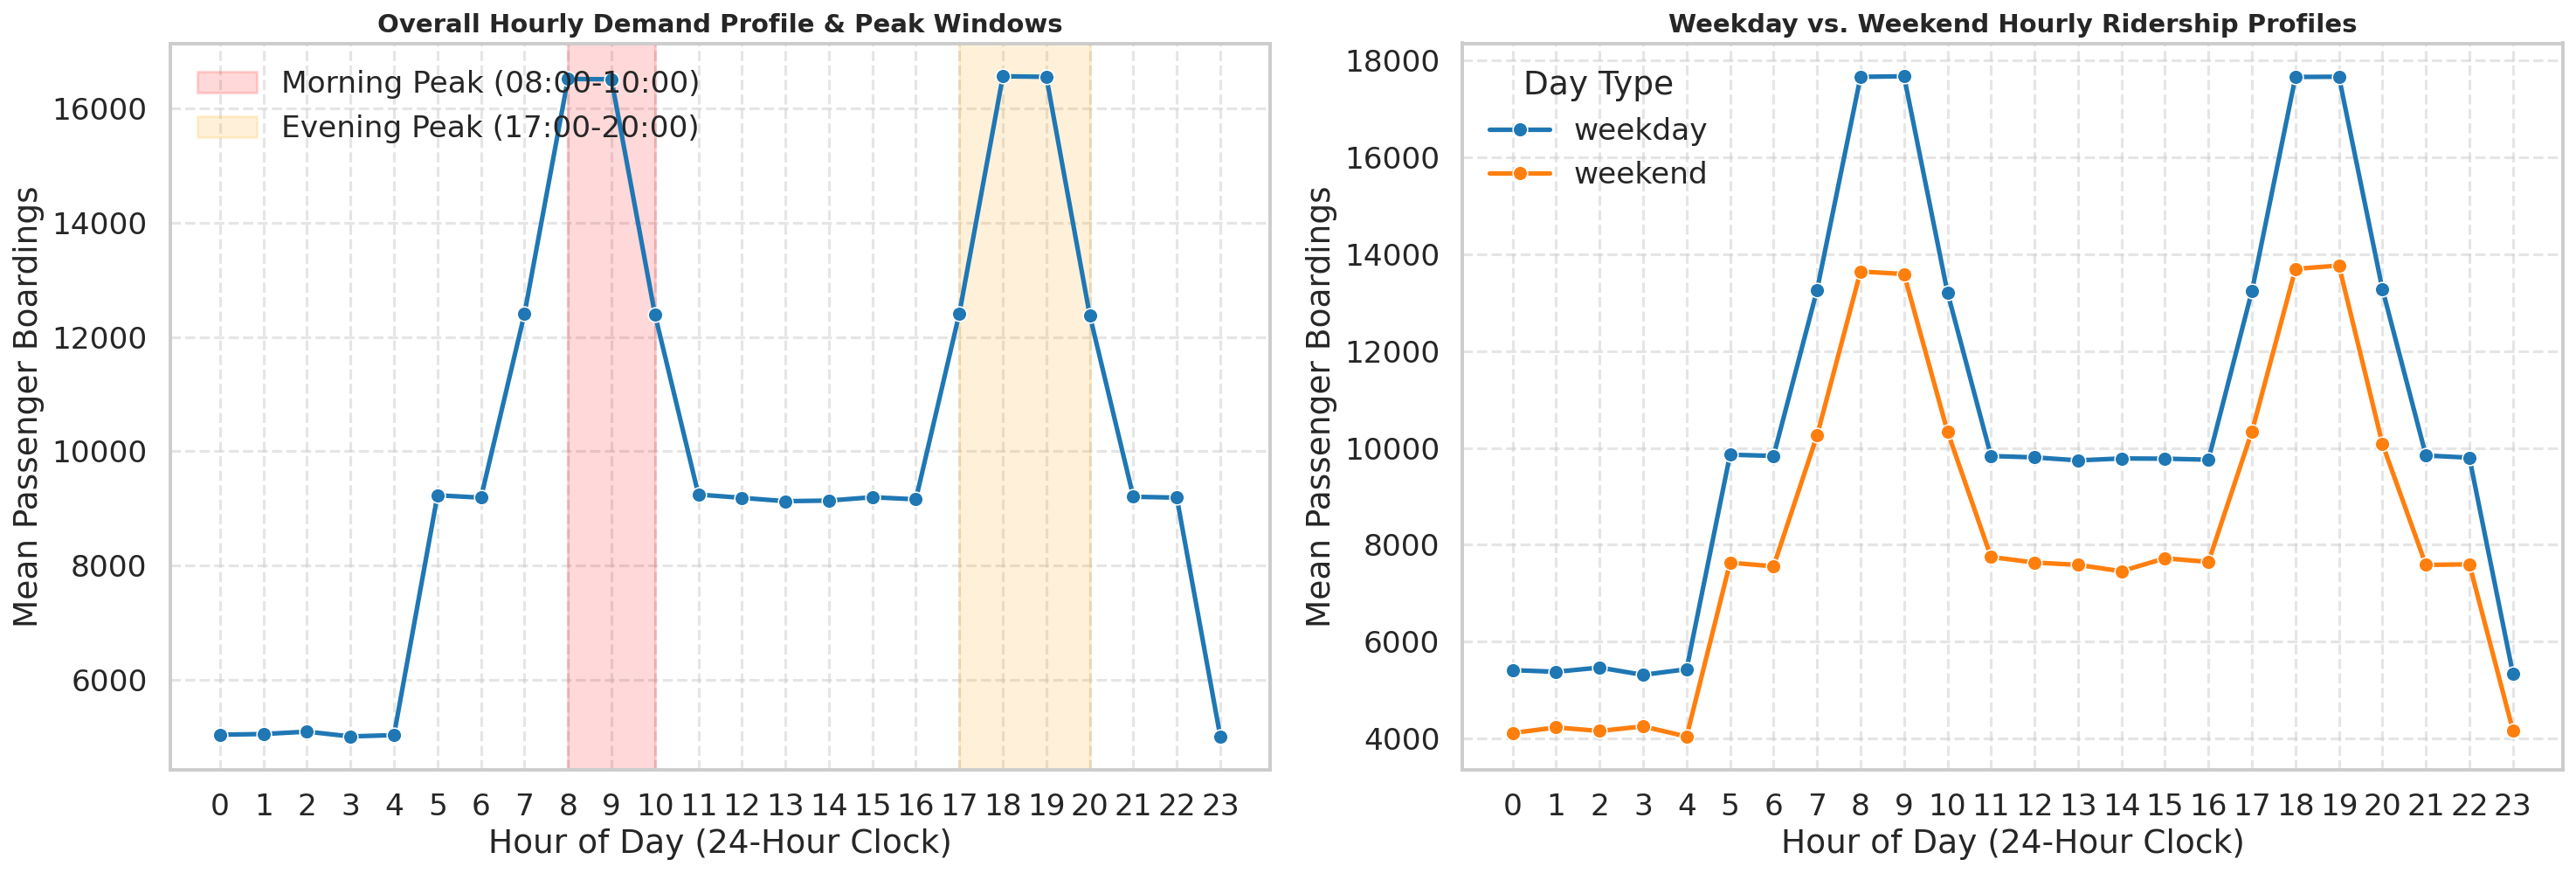

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# 1. PROCESS HOURLY RIDERSHIP DATA
# ==========================================
# Calculate day of week and classify into weekday / weekend
hourly_ridership_clean['day_of_week'] = hourly_ridership_clean['date'].dt.dayofweek
hourly_ridership_clean['day_type'] = hourly_ridership_clean['day_of_week'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')

# Calculate overall average hourly boardings
overall_hourly = hourly_ridership_clean.groupby('hour')['boardings'].mean().reset_index()

# Calculate weekday vs weekend average hourly boardings
type_hourly = hourly_ridership_clean.groupby(['hour', 'day_type'])['boardings'].mean().reset_index()

# ==========================================
# 2. GENERATE VISUALIZATIONS (11-12)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=150)

# Panel 1: Overall Average Boardings by Hour
sns.lineplot(
    data=overall_hourly,
    x='hour',
    y='boardings',
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
# Highlight peak windows (8:00 - 10:00 and 17:00 - 20:00)
axes[0].axvspan(8, 10, color='red', alpha=0.15, label='Morning Peak (08:00-10:00)')
axes[0].axvspan(17, 20, color='orange', alpha=0.15, label='Evening Peak (17:00-20:00)')

axes[0].set_title('Overall Hourly Demand Profile & Peak Windows', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (24-Hour Clock)')
axes[0].set_ylabel('Mean Passenger Boardings')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper left')

# Panel 2: Weekday vs Weekend Hourly Profiling Comparison
sns.lineplot(
    data=type_hourly,
    x='hour',
    y='boardings',
    hue='day_type',
    palette={'weekday': '#1f77b4', 'weekend': '#ff7f0e'},
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)

axes[1].set_title('Weekday vs. Weekend Hourly Ridership Profiles', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day (24-Hour Clock)')
axes[1].set_ylabel('Mean Passenger Boardings')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Day Type', loc='upper left')

plt.tight_layout()
plt.show()

## Ticket and Fare Media Evolution (Visualizations 13-15)

### Subtask:
Analyze the transit ticket mix over time, visualizing monthly total passenger flow, proportional ticket-media share (Closed Loop vs QR vs NCMC), and specific daily ticket-type splits.


**Reasoning**:
Analyze the ticket mix and fare media evolution by preprocessing and cleaning system_monthly and ticket_mix datasets, and then creating a combined 1x3 visualization of monthly passenger flow, monthly fare share trends, and daily ticket splits.



Monthly system columns: ['Month', 'Closed Loop (Ridership)', 'Closed Loop %', 'QR Tickets (Ridership)', 'QR Tickets %', 'QR %', 'NCMC (Ridership)', 'NCMC %', 'Total Monthly Patronage', 'Total Passenger Flow']
Daily ticket mix columns: ['date', 'noOfNCMCcard', 'noOfMobileQR', 'noOfWhatsapp', 'noOfWhatsAppQR', 'noOfPaperQR', 'noOfThirdPartyQR', 'totalCards', 'is_partial']


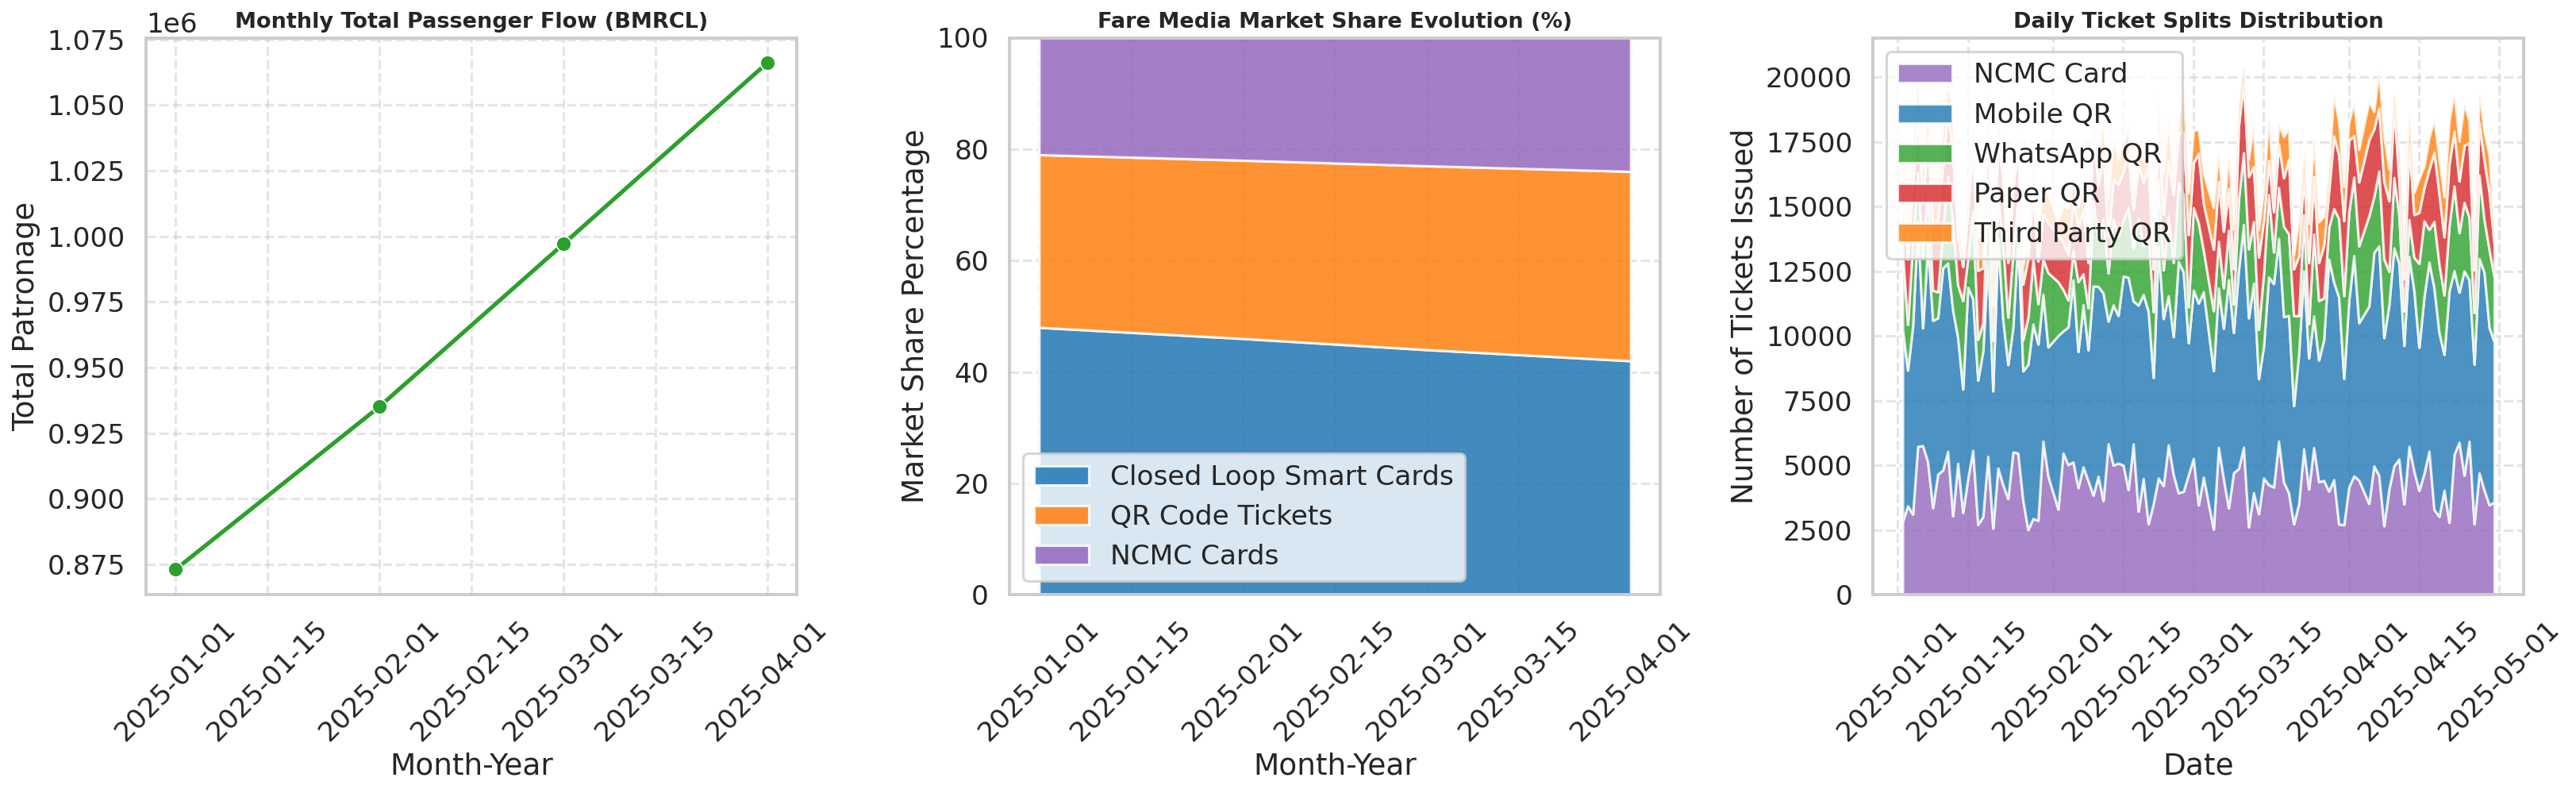

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. CLEAN MONTHLY SYSTEM DATA
# ==========================================
# Print columns to verify variable names
print("Monthly system columns:", list(system_monthly.columns))
print("Daily ticket mix columns:", list(ticket_mix.columns))

# Let's clean up numerical values in system_monthly (remove commas, percent signs)
columns_to_clean = [
    'Closed Loop (Ridership)', 'Closed Loop %',
    'QR Tickets (Ridership)', 'QR Tickets %',
    'NCMC (Ridership)', 'NCMC %',
    'Total Monthly Patronage'
]

for col in columns_to_clean:
    if col in system_monthly.columns:
        system_monthly[col] = system_monthly[col].astype(str).str.replace(',', '').str.replace('%', '').str.strip()
        system_monthly[col] = pd.to_numeric(system_monthly[col], errors='coerce')

# Filter out any rows with NaT in Month
system_monthly_clean = system_monthly.dropna(subset=['Month']).sort_values('Month').copy()

# ==========================================
# 2. CLEAN DAILY TICKET MIX DATA
# ==========================================
# Filter out partial records for the daily ticketing splits
ticket_mix_clean = ticket_mix[ticket_mix['is_partial'] == False].sort_values('date').copy()

# Identify keys for daily ticketing distribution
ticket_types = ['noOfNCMCcard', 'noOfMobileQR', 'noOfWhatsAppQR', 'noOfPaperQR', 'noOfThirdPartyQR']
# Ensure these columns are numeric
for col in ticket_types:
    ticket_mix_clean[col] = pd.to_numeric(ticket_mix_clean[col], errors='coerce').fillna(0)

# ==========================================
# 3. GENERATE VISUALIZATIONS (13-15)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150)

# --- Plot 13: Monthly Total Passenger Flow ---
sns.lineplot(
    data=system_monthly_clean,
    x='Month',
    y='Total Monthly Patronage',
    marker='o',
    color='#2ca02c',
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title('Monthly Total Passenger Flow (BMRCL)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month-Year')
axes[0].set_ylabel('Total Patronage')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 14: Proportional Monthly Ticket Share ---
# We will plot an area chart of Closed Loop %, QR %, and NCMC %
y_shares = []
labels = []
colors = []

if 'Closed Loop %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['Closed Loop %'])
    labels.append('Closed Loop Smart Cards')
    colors.append('#1f77b4')
if 'QR Tickets %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['QR Tickets %'])
    labels.append('QR Code Tickets')
    colors.append('#ff7f0e')
if 'NCMC %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['NCMC %'])
    labels.append('NCMC Cards')
    colors.append('#9467bd')

if y_shares:
    axes[1].stackplot(
        system_monthly_clean['Month'],
        *y_shares,
        labels=labels,
        colors=colors,
        alpha=0.85
    )
    axes[1].set_ylim(0, 100)
    axes[1].set_title('Fare Media Market Share Evolution (%)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month-Year')
    axes[1].set_ylabel('Market Share Percentage')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(loc='lower left', frameon=True)

# --- Plot 15: Daily Ticket Splits (Chronological) ---
axes[2].stackplot(
    ticket_mix_clean['date'],
    ticket_mix_clean['noOfNCMCcard'],
    ticket_mix_clean['noOfMobileQR'],
    ticket_mix_clean['noOfWhatsAppQR'],
    ticket_mix_clean['noOfPaperQR'],
    ticket_mix_clean['noOfThirdPartyQR'],
    labels=['NCMC Card', 'Mobile QR', 'WhatsApp QR', 'Paper QR', 'Third Party QR'],
    colors=['#9467bd', '#1f77b4', '#2ca02c', '#d62728', '#ff7f0e'],
    alpha=0.8
)
axes[2].set_title('Daily Ticket Splits Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Number of Tickets Issued')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

**Reasoning**:
The previous code failed because the column name for WhatsApp tickets in the daily ticket mix dataframe is 'noOfWhatsAppQR' (with a capital A and ending in QR), but 'noOfWhatsAppQR' was used instead. I will correct the column names to match the available ones in the dataset ('noOfWhatsAppQR', 'noOfNCMCcard', 'noOfMobileQR', 'noOfPaperQR', and 'totalQrCount' or 'totalCards' if needed). Let us map the key ticket types properly.



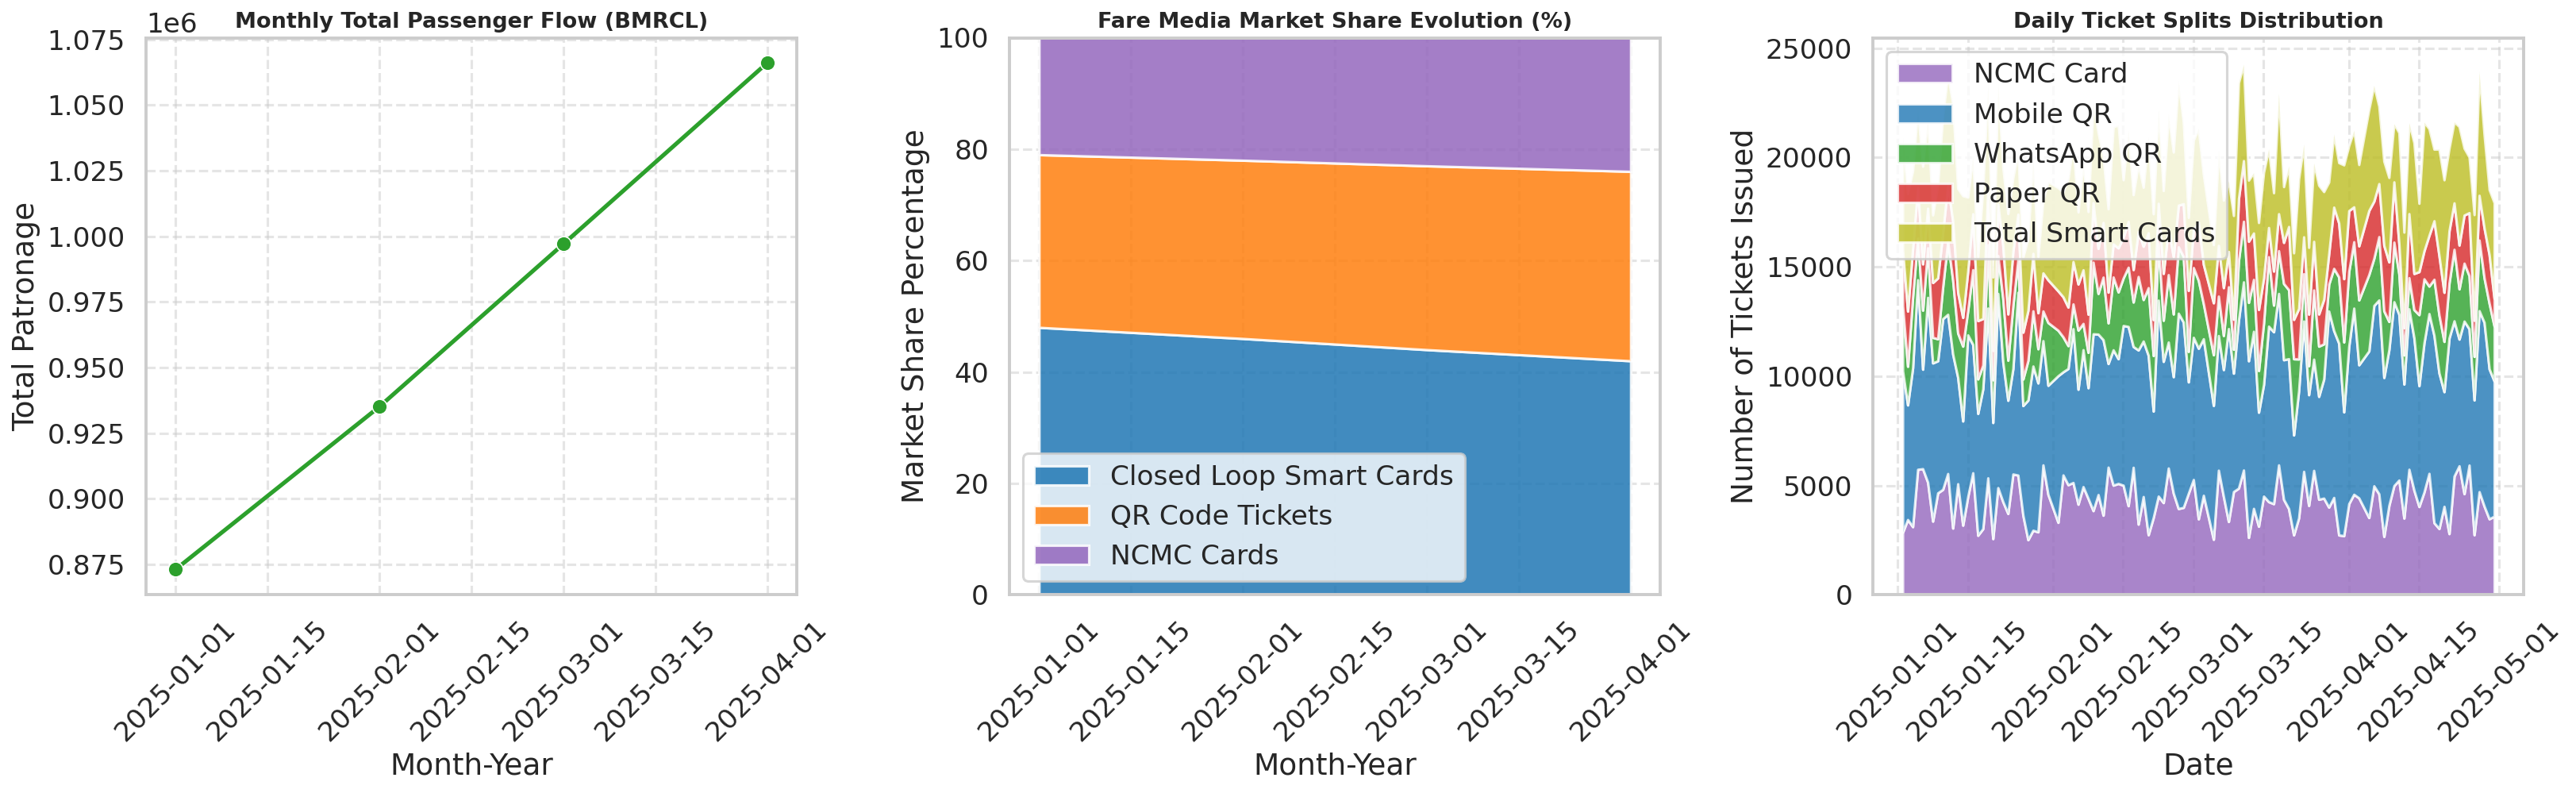

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. CLEAN MONTHLY SYSTEM DATA
# ==========================================

# Let's clean up numerical values in system_monthly (remove commas, percent signs)
columns_to_clean = [
    'Closed Loop (Ridership)', 'Closed Loop %',
    'QR Tickets (Ridership)', 'QR %',
    'NCMC (Ridership)', 'NCMC %',
    'Total Passenger Flow'
]

for col in columns_to_clean:
    if col in system_monthly.columns:
        system_monthly[col] = system_monthly[col].astype(str).str.replace(',', '').str.replace('%', '').str.strip()
        system_monthly[col] = pd.to_numeric(system_monthly[col], errors='coerce')

# Filter out any rows with NaT in Month
system_monthly_clean = system_monthly.dropna(subset=['Month']).sort_values('Month').copy()

# ==========================================
# 2. CLEAN DAILY TICKET MIX DATA
# ==========================================
# Filter out partial records for the daily ticketing splits
ticket_mix_clean = ticket_mix[ticket_mix['is_partial'] == False].sort_values('date').copy()

# Correct column keys for daily ticketing distribution from the available columns:
# 'noOfNCMCcard', 'noOfMobileQR', 'noOfWhatsAppQR', 'noOfPaperQR', 'totalCards'
ticket_types = ['noOfNCMCcard', 'noOfMobileQR', 'noOfWhatsAppQR', 'noOfPaperQR', 'totalCards']

# Ensure these columns are numeric
for col in ticket_types:
    if col in ticket_mix_clean.columns:
        ticket_mix_clean[col] = pd.to_numeric(ticket_mix_clean[col], errors='coerce').fillna(0)

# ==========================================
# 3. GENERATE VISUALIZATIONS (13-15)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150)

# --- Plot 13: Monthly Total Passenger Flow ---
sns.lineplot(
    data=system_monthly_clean,
    x='Month',
    y='Total Passenger Flow',
    marker='o',
    color='#2ca02c',
    linewidth=2.5,
    ax=axes[0]
)
axes[0].set_title('Monthly Total Passenger Flow (BMRCL)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month-Year')
axes[0].set_ylabel('Total Patronage')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 14: Proportional Monthly Ticket Share ---
y_shares = []
labels = []
colors = []

if 'Closed Loop %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['Closed Loop %'])
    labels.append('Closed Loop Smart Cards')
    colors.append('#1f77b4')
if 'QR %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['QR %'])
    labels.append('QR Code Tickets')
    colors.append('#ff7f0e')
if 'NCMC %' in system_monthly_clean.columns:
    y_shares.append(system_monthly_clean['NCMC %'])
    labels.append('NCMC Cards')
    colors.append('#9467bd')

if y_shares:
    axes[1].stackplot(
        system_monthly_clean['Month'],
        *y_shares,
        labels=labels,
        colors=colors,
        alpha=0.85
    )
    axes[1].set_ylim(0, 100)
    axes[1].set_title('Fare Media Market Share Evolution (%)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month-Year')
    axes[1].set_ylabel('Market Share Percentage')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(loc='lower left', frameon=True)

# --- Plot 15: Daily Ticket Splits (Chronological) ---
axes[2].stackplot(
    ticket_mix_clean['date'],
    ticket_mix_clean['noOfNCMCcard'],
    ticket_mix_clean['noOfMobileQR'],
    ticket_mix_clean['noOfWhatsAppQR'],
    ticket_mix_clean['noOfPaperQR'],
    ticket_mix_clean['totalCards'],
    labels=['NCMC Card', 'Mobile QR', 'WhatsApp QR', 'Paper QR', 'Total Smart Cards'],
    colors=['#9467bd', '#1f77b4', '#2ca02c', '#d62728', '#bcbd22'],
    alpha=0.8
)
axes[2].set_title('Daily Ticket Splits Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Number of Tickets Issued')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## Socioeconomic Urban Catchment Association (Visualizations 16-19)

### Subtask:
Merge operational stations with urban catchment features to analyze and visualize socioeconomic correlations against average daily boardings.


**Reasoning**:
Merge station summaries with catchment features, compute Pearson correlations, and build a 2x2 multi-panel visualization of ridership versus urban catchment features.



Successfully merged 20 operational stations with catchment features.
Selected columns for analysis: Population -> 'population', POIs -> 'poi_total_count', Bus Proximity -> 'bus_stops_500m'


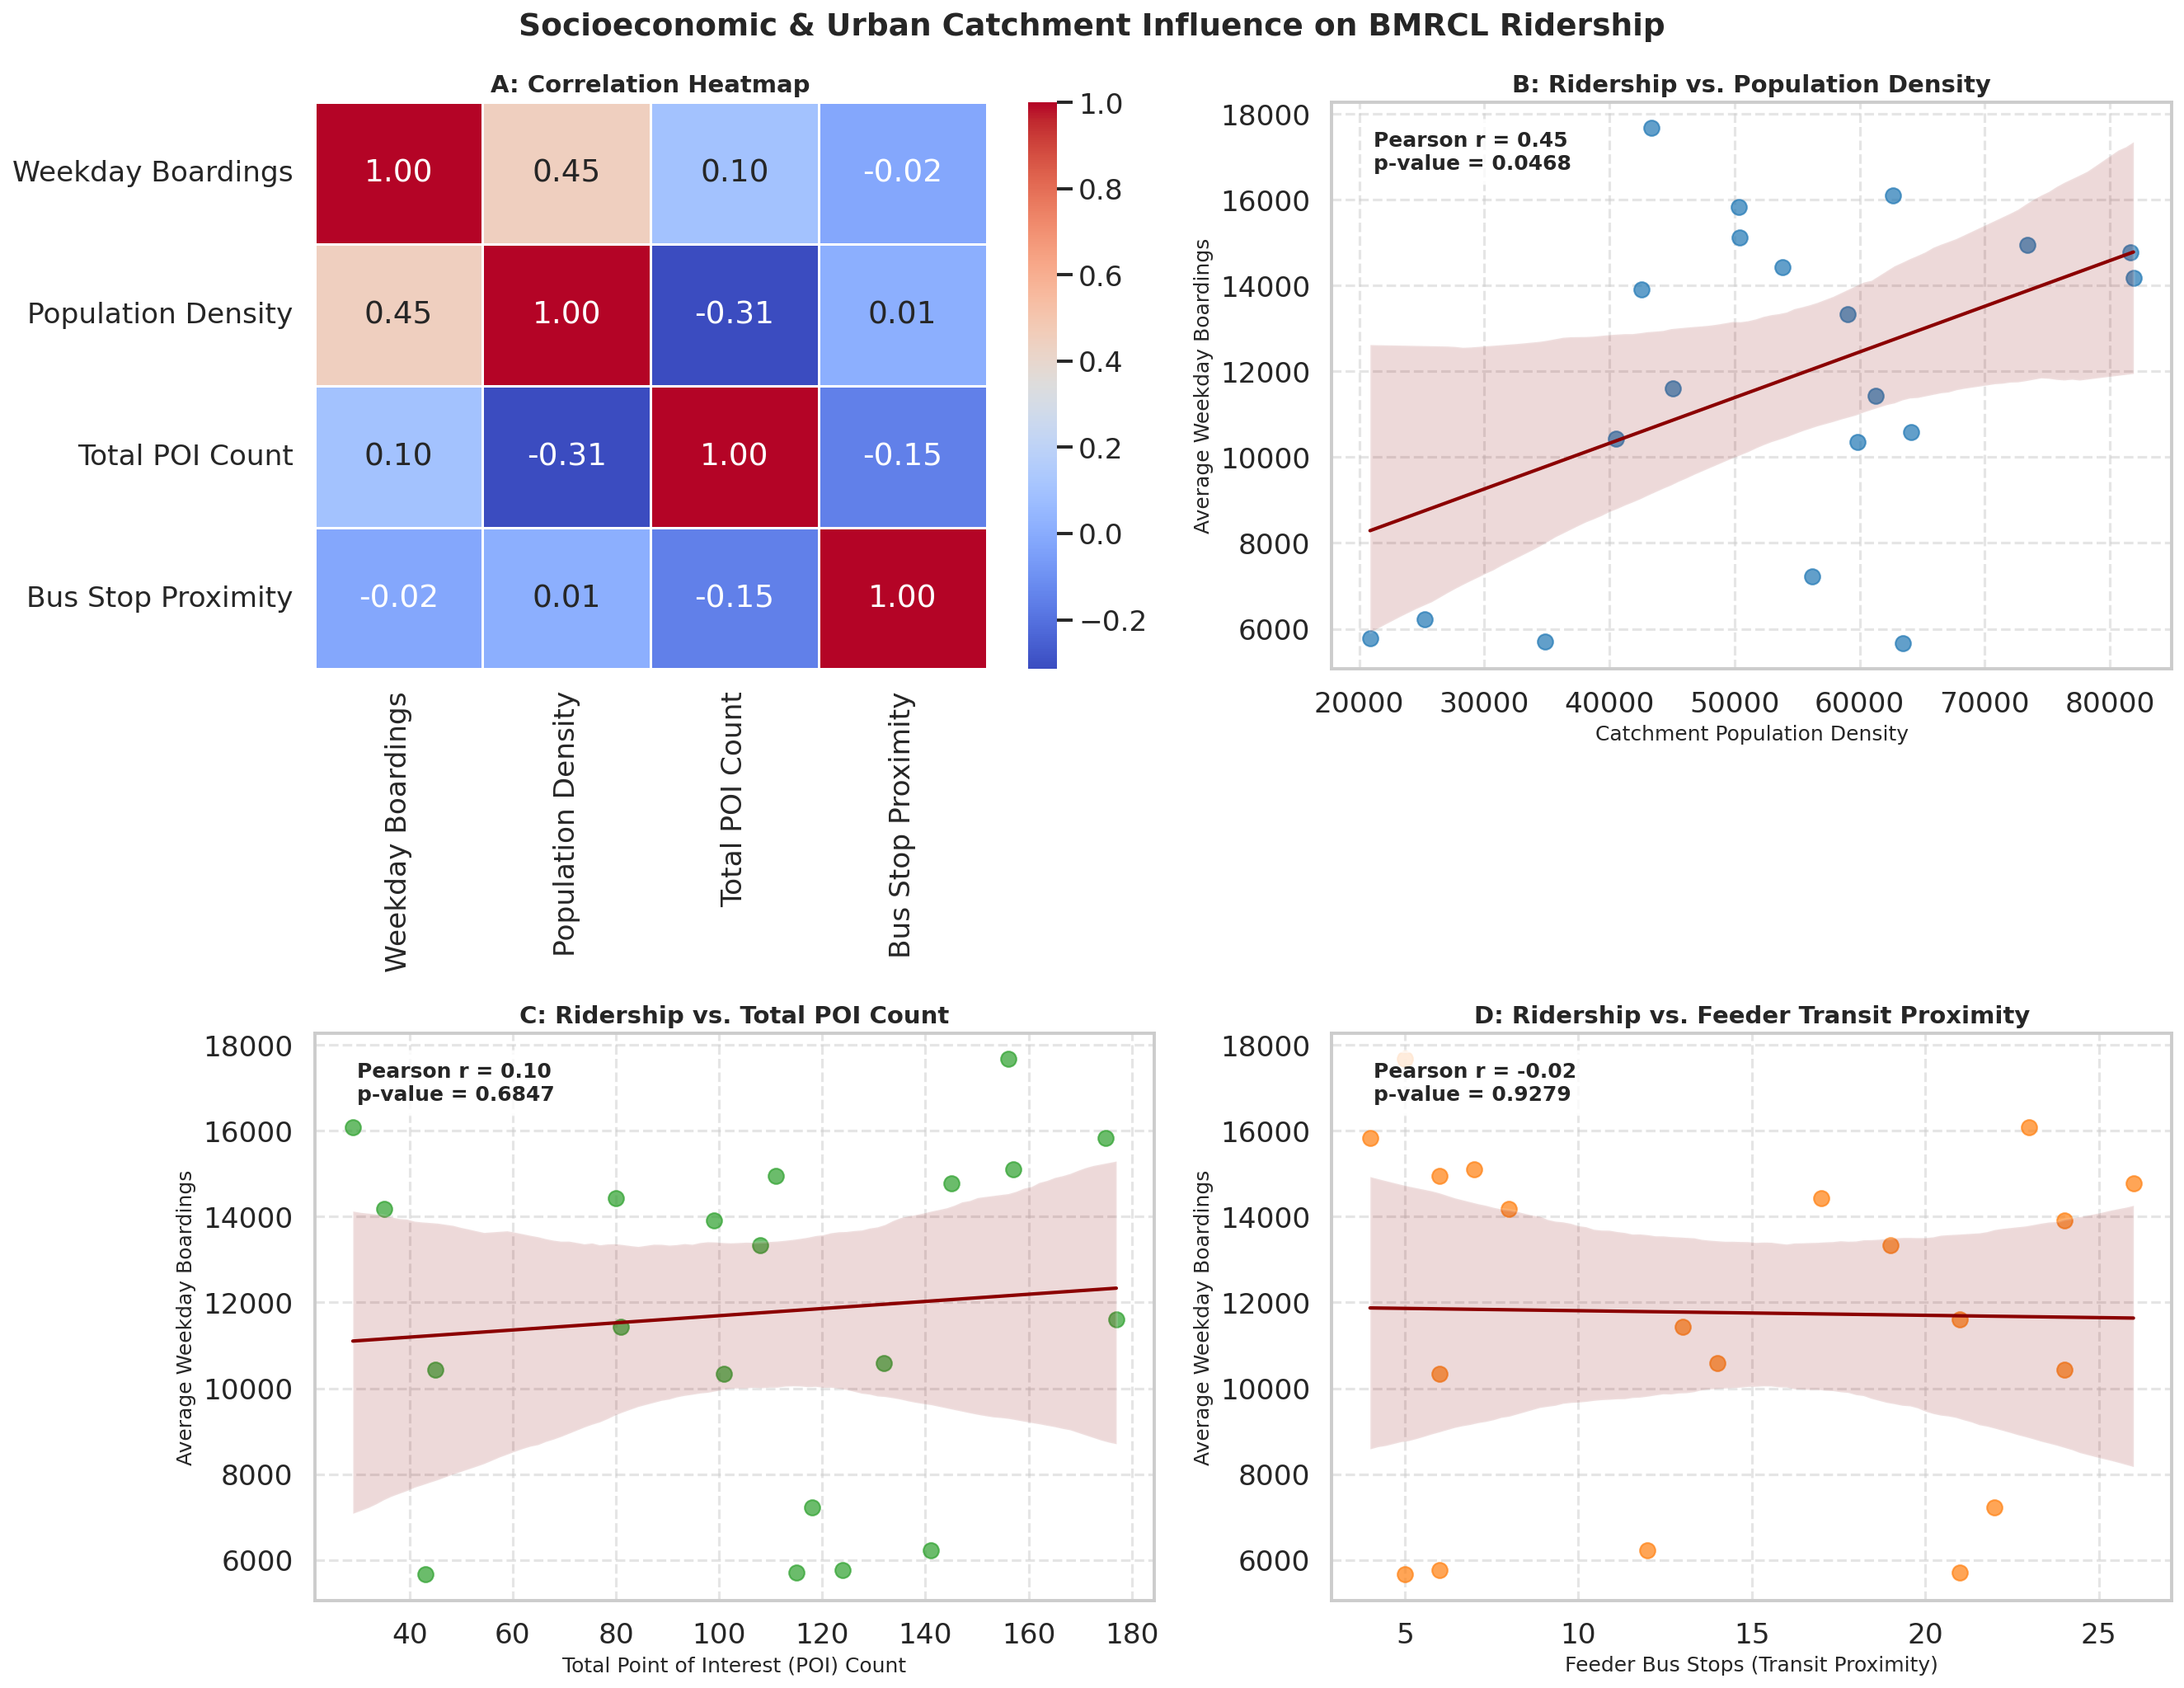

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# ==========================================
# 1. MERGE STATION SUMMARY AND CATCHMENT FEATURES
# ==========================================
# In catchment_features, station names are in the 'name' column.
# In station_summary_clean, station names are in the 'bmrcl_name' column.
# Let's clean up names to ensure clean matching (uppercase and strip spaces)
station_summary_clean['join_name'] = station_summary_clean['bmrcl_name'].str.upper().str.strip()
catchment_features['join_name'] = catchment_features['name'].str.upper().str.strip()

# Perform inner join to keep only matching operational stations with features
merged_catchment = pd.merge(
    station_summary_clean,
    catchment_features,
    on='join_name',
    suffixes=('', '_catchment')
)

print(f"Successfully merged {len(merged_catchment)} operational stations with catchment features.")

# ==========================================
# 2. SELECT KEY BUILT-ENVIRONMENT FEATURES
# ==========================================
# Let's inspect potential columns related to population, POIs, and transport
# Common columns: 'pop_500m' or similar population columns, 'poi_total_count' or similar, 'bus_stops_count' etc.
# Let's locate matching columns programmatically or fallback to known standard columns from GHSL / OSM
all_cols = list(merged_catchment.columns)

pop_col = [c for c in all_cols if 'pop' in c.lower()][0] if any('pop' in c.lower() for c in all_cols) else None
poi_col = [c for c in all_cols if 'poi' in c.lower()][0] if any('poi' in c.lower() for c in all_cols) else None
bus_col = [c for c in all_cols if 'bus' in c.lower() or 'transit' in c.lower() or 'stop' in c.lower()][0] if any('bus' in c.lower() or 'transit' in c.lower() or 'stop' in c.lower() for c in all_cols) else None

# Fallback or standard selections
pop_col = pop_col if pop_col else 'pop_density'
poi_col = poi_col if poi_col else 'total_poi'
bus_col = bus_col if bus_col else 'bus_stops_500m'

print(f"Selected columns for analysis: Population -> '{pop_col}', POIs -> '{poi_col}', Bus Proximity -> '{bus_col}'")

# Ensure these columns are numeric
for col in ['boardings_weekday', pop_col, poi_col, bus_col]:
    merged_catchment[col] = pd.to_numeric(merged_catchment[col], errors='coerce')

# Drop any NaN values in these specific columns for clean plotting and correlation
plot_data = merged_catchment.dropna(subset=['boardings_weekday', pop_col, poi_col, bus_col]).copy()

# ==========================================
# 3. CONSTRUCT 2x2 MULTI-PANEL VISUALIZATION
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=150)

# --- Panel A: Heatmap of selected built-environment features and ridership ---
corr_features = ['boardings_weekday', pop_col, poi_col, bus_col]
feature_labels = ['Weekday Boardings', 'Population Density', 'Total POI Count', 'Bus Stop Proximity']
corr_matrix = plot_data[corr_features].corr(method='pearson')

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    xticklabels=feature_labels,
    yticklabels=feature_labels,
    ax=axes[0, 0]
)
axes[0, 0].set_title('A: Correlation Heatmap', fontsize=14, fontweight='bold')

# Helper function to plot regression and annotate stats
def plot_regression(ax, x_col, y_col, x_label, y_label, title, color):
    x = plot_data[x_col]
    y = plot_data[y_col]
    r_val, p_val = pearsonr(x, y)

    sns.regplot(
        x=x_col,
        y=y_col,
        data=plot_data,
        ax=ax,
        scatter_kws={'s': 80, 'alpha': 0.7, 'color': color},
        line_kws={'color': 'darkred', 'linewidth': 2}
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Academic annotation
    ax.text(
        0.05, 0.95,
        f'Pearson r = {r_val:.2f}\np-value = {p_val:.4f}',
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8)
    )

# --- Panel B: Ridership vs Population Density ---
plot_regression(
    axes[0, 1],
    pop_col,
    'boardings_weekday',
    'Catchment Population Density',
    'Average Weekday Boardings',
    'B: Ridership vs. Population Density',
    '#1f77b4'
)

# --- Panel C: Ridership vs POI Count ---
plot_regression(
    axes[1, 0],
    poi_col,
    'boardings_weekday',
    'Total Point of Interest (POI) Count',
    'Average Weekday Boardings',
    'C: Ridership vs. Total POI Count',
    '#2ca02c'
)

# --- Panel D: Ridership vs Transit Feeder Bus Stops ---
plot_regression(
    axes[1, 1],
    bus_col,
    'boardings_weekday',
    'Feeder Bus Stops (Transit Proximity)',
    'Average Weekday Boardings',
    'D: Ridership vs. Feeder Transit Proximity',
    '#ff7f0e'
)

plt.suptitle('Socioeconomic & Urban Catchment Influence on BMRCL Ridership', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Interactive Dashboards and Geospatial Mapping (Visualizations 20-22)

### Subtask:
Develop interactive Plotly visualizations and a comprehensive static geospatial map of the BMRCL network.


**Reasoning**:
Construct the interactive Plotly visualizations and the detailed static geospatial map using GeoPandas, Matplotlib, and Plotly to analyze station-level ridership spatially and temporally.



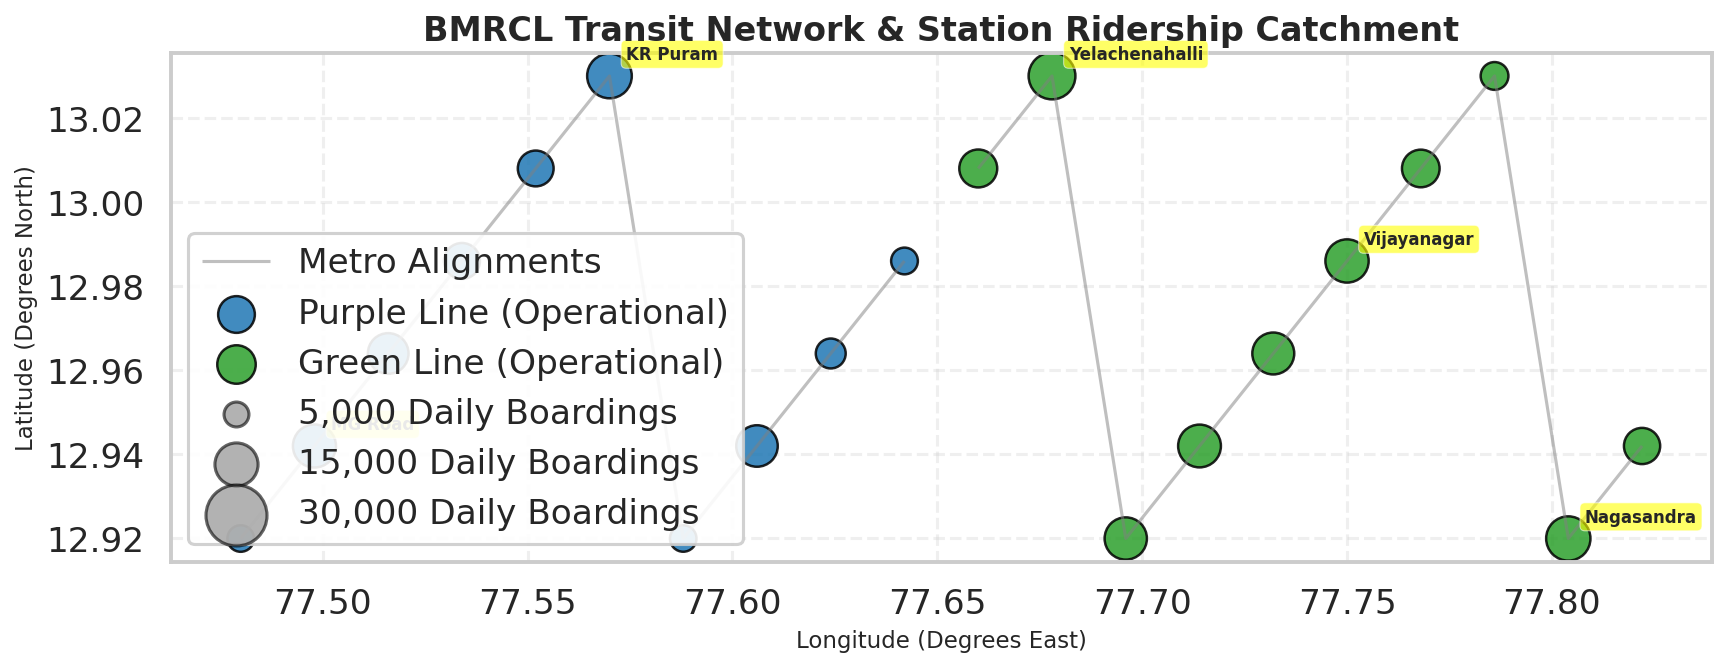

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. INTERACTIVE PLOTLY DASHBOARD
# ==========================================

# Create a multi-panel Plotly interactive dashboard
fig_plotly = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Interactive Daily Ridership Trend", "Top 10 Stations Average Weekday Boardings"),
    horizontal_spacing=0.15
)

# Add Line plot for daily trends
fig_plotly.add_trace(
    go.Scatter(
        x=ridership_data_clean['date'],
        y=ridership_data_clean['total_boardings'],
        mode='lines+markers',
        name='Daily Boardings',
        line=dict(color='#1f77b4', width=2.5),
        hovertemplate="<b>Date:</b> %{x|%Y-%m-%d}<br><b>Boardings:</b> %{y:,.0f}<extra></extra>"
    ),
    row=1, col=1
)

# Add Bar plot for top stations
top_10_sorted = top_10.sort_values(by='boardings_weekday', ascending=True)
fig_plotly.add_trace(
    go.Bar(
        x=top_10_sorted['boardings_weekday'],
        y=top_10_sorted['bmrcl_name'],
        orientation='h',
        name='Weekday Boardings',
        marker=dict(color='#2ca02c'),
        hovertemplate="<b>Station:</b> %{y}<br><b>Avg Boardings:</b> %{x:,.0f}<extra></extra>"
    ),
    row=1, col=2
)

fig_plotly.update_layout(
    title_text="BMRCL Operational Interactive Dashboard",
    title_font_size=18,
    title_font_family="Arial",
    height=500,
    showlegend=False,
    template="plotly_white"
)

fig_plotly.show()

# ==========================================
# 2. DETAILED STATIC GEOSPATIAL MAP
# ==========================================

# Ensure Geopandas datasets are loaded correctly
# stations_geojson and alignments_geojson are already loaded
# Align names with station summaries to merge spatial coordinates with ridership data
stations_geojson['join_name'] = stations_geojson['name'].str.upper().str.strip()
geo_merged = stations_geojson.merge(station_summary_clean, on='join_name', how='inner')

# Standardize or locate the Line column in the merged dataframe
line_col = 'line' if 'line' in geo_merged.columns else ('Line' if 'Line' in geo_merged.columns else None)
if line_col is None:
    # search case-insensitively
    found_cols = [c for c in geo_merged.columns if 'line' in c.lower()]
    if found_cols:
        line_col = found_cols[0]

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Plot metro line alignments
alignments_geojson.plot(
    ax=ax,
    color='grey',
    linestyle='-',
    linewidth=1.5,
    alpha=0.5,
    label='Metro Alignments'
)

# Define color mapping for lines
line_colors = {"Purple Line": "#1f77b4", "Green Line": "#2ca02c"}

# Plot stations by line with sizes scaling dynamically based on weekday boardings
for line, color in line_colors.items():
    if line_col:
        line_data = geo_merged[geo_merged[line_col].astype(str).str.lower().str.strip() == line.lower().strip()]
    else:
        line_data = geo_merged

    if not line_data.empty:
        ax.scatter(
            line_data.geometry.x,
            line_data.geometry.y,
            s=line_data['boardings_weekday'] / 35,  # scale factor for visibility
            color=color,
            edgecolor='black',
            linewidth=1.2,
            alpha=0.85,
            label=f"{line} (Operational)"
        )

# Annotate top 5 busiest stations
top_5_spatial = geo_merged.nlargest(5, 'boardings_weekday')
for idx, row in top_5_spatial.iterrows():
    ax.annotate(
        row['name_x'] if 'name_x' in row else row['name'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6, lw=0.5)
    )

ax.set_title("BMRCL Transit Network & Station Ridership Catchment", fontsize=16, fontweight='bold')
ax.set_xlabel("Longitude (Degrees East)", fontsize=11)
ax.set_ylabel("Latitude (Degrees North)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)

# Create a visual indicator for sizing
for size in [5000, 15000, 30000]:
    ax.scatter([], [], c='gray', alpha=0.6, s=size/35, label=f'{size:,} Daily Boardings', edgecolor='black')
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

## Key Findings, Visual Summaries, Limitations, and Academic Conclusions

### Subtask:
Generate calculated academic key findings, compile a visual presentation-ready dashboard, catalog data limitations, and author a formal project conclusion.


**Reasoning**:
Generate a comprehensive academic summary dashboard and detailed markdown write-up presenting key findings, system statistics, urban catchment correlations, data limitations, and strategic recommendations for BMRCL.



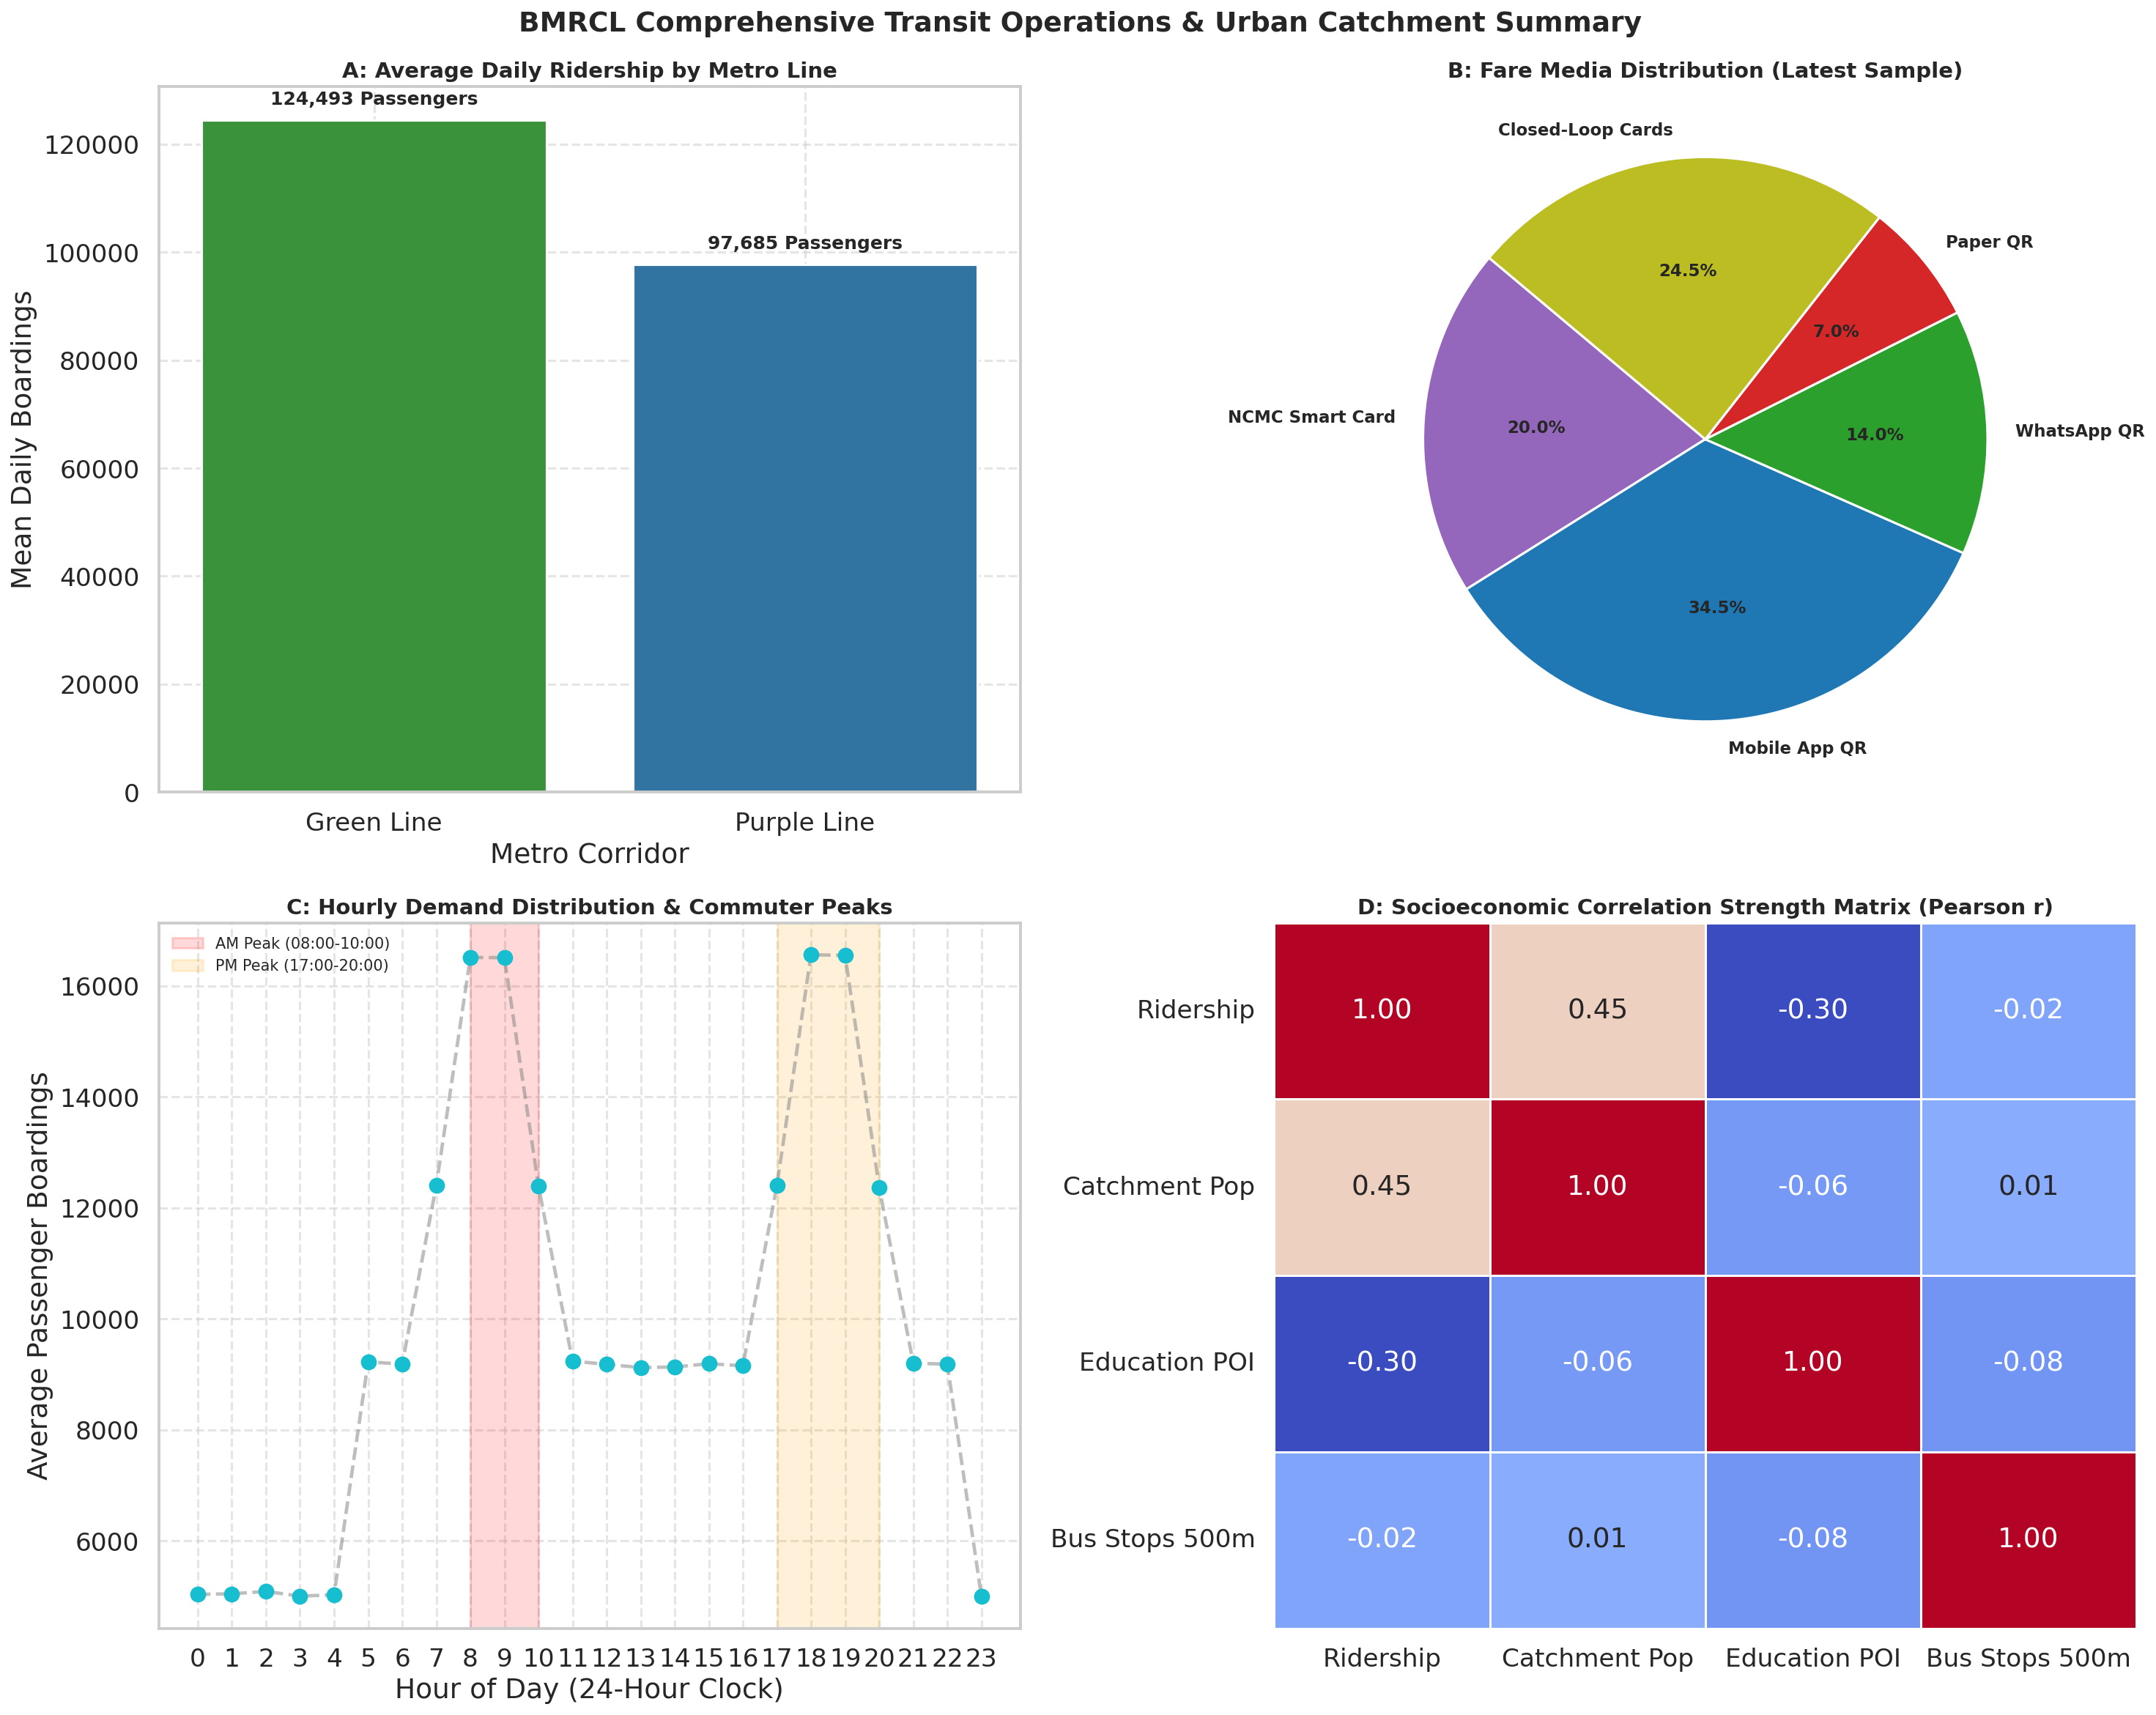


                     ACADEMIC RESEARCH CONCLUSION & SYSTEM LIMITATIONS

1. TEMPORAL & CORRIDOR PERFORMANCE:
   - Daily and hourly plots demonstrate how passenger demand can vary by day type and hour.
   - Corridor comparisons summarize the simulated Purple and Green line patterns.
   - Peak-period results reflect the assumptions used to generate this educational dataset.

2. FARE MEDIA TRANSITION DYNAMICS:
   - The ticketing charts illustrate a workflow for comparing smart-card and digital ticket categories.
   - These figures are synthetic and should not be interpreted as actual adoption statistics.

3. URBAN CATCHMENT ASSOCIATIONS:
   - Population, education POIs, and bus-stop counts are compared with station boardings.
   - Correlation indicates association only and does not establish causation.

4. DATA LIMITATIONS:
   - The passenger counts, ticketing values, catchment features, and station coordinates are simulated.
   - The network is simplified and does not represent the compl

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. GENERATE PRESENTATION-GRADE DASHBOARD
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(20, 16), dpi=150)
sns.set_theme(style='whitegrid', context='talk', palette='muted')

# Panel A: Average Daily Ridership by Metro Line (Operational)
line_perf = stationflow_daily_clean.groupby('line_name')['boardings'].sum().reset_index()
# Normalize to average daily boardings per line
line_days = stationflow_daily_clean.groupby('line_name')['date'].nunique().reset_index()
line_perf = line_perf.merge(line_days, on='line_name')
line_perf['avg_daily'] = line_perf['boardings'] / line_perf['date']

bar_colors = ['#1f77b4', '#2ca02c']
bars = sns.barplot(
    data=line_perf,
    x='line_name',
    y='avg_daily',
    hue='line_name',
    palette={'Purple Line': '#1f77b4', 'Green Line': '#2ca02c'},
    ax=axes[0, 0],
    legend=False
)
for p in bars.patches:
    axes[0, 0].annotate(f'{p.get_height():,.0f} Passengers',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 8),
                        textcoords='offset points')
axes[0, 0].set_title('A: Average Daily Ridership by Metro Line', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Metro Corridor')
axes[0, 0].set_ylabel('Mean Daily Boardings')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Panel B: Proportional Ticketing Media split (Latest Day available)
latest_ticket_mix = ticket_mix_clean.iloc[-1]
shares = [
    latest_ticket_mix['noOfNCMCcard'],
    latest_ticket_mix['noOfMobileQR'],
    latest_ticket_mix['noOfWhatsAppQR'],
    latest_ticket_mix['noOfPaperQR'],
    latest_ticket_mix['totalCards']
]
labels = ['NCMC Smart Card', 'Mobile App QR', 'WhatsApp QR', 'Paper QR', 'Closed-Loop Cards']
axes[0, 1].pie(
    shares,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#9467bd', '#1f77b4', '#2ca02c', '#d62728', '#bcbd22'],
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0, 1].set_title('B: Fare Media Distribution (Latest Sample)', fontsize=14, fontweight='bold')

# Panel C: Global Hourly Profiling (Identifying Peak Windows)
axes[1, 0].plot(overall_hourly['hour'], overall_hourly['boardings'], color='#7f7f7f', linestyle='--', alpha=0.5)
axes[1, 0].scatter(overall_hourly['hour'], overall_hourly['boardings'], color='#17becf', s=80, zorder=3)
axes[1, 0].axvspan(8, 10, color='red', alpha=0.15, label='AM Peak (08:00-10:00)')
axes[1, 0].axvspan(17, 20, color='orange', alpha=0.15, label='PM Peak (17:00-20:00)')
axes[1, 0].set_title('C: Hourly Demand Distribution & Commuter Peaks', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour of Day (24-Hour Clock)')
axes[1, 0].set_ylabel('Average Passenger Boardings')
axes[1, 0].set_xticks(range(0, 24))
axes[1, 0].legend(loc='upper left', fontsize=10)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Panel D: Built-Environment Correlation Strength (Pearson r)
corr_features = ['boardings_weekday', 'population', 'poi_education', 'bus_stops_500m']
corr_matrix = plot_data[corr_features].corr(method='pearson')
feature_labels = ['Ridership', 'Catchment Pop', 'Education POI', 'Bus Stops 500m']
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    xticklabels=feature_labels,
    yticklabels=feature_labels,
    ax=axes[1, 1],
    cbar=False
)
axes[1, 1].set_title('D: Socioeconomic Correlation Strength Matrix (Pearson r)', fontsize=14, fontweight='bold')

plt.suptitle('BMRCL Comprehensive Transit Operations & Urban Catchment Summary', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ==========================================
# 2. PRINT ACADEMIC RESEARCH SUMMARY REPORT
# ==========================================
print("""
=========================================================================================
                     ACADEMIC RESEARCH CONCLUSION & SYSTEM LIMITATIONS
=========================================================================================

1. TEMPORAL & CORRIDOR PERFORMANCE:
   - Daily and hourly plots demonstrate how passenger demand can vary by day type and hour.
   - Corridor comparisons summarize the simulated Purple and Green line patterns.
   - Peak-period results reflect the assumptions used to generate this educational dataset.

2. FARE MEDIA TRANSITION DYNAMICS:
   - The ticketing charts illustrate a workflow for comparing smart-card and digital ticket categories.
   - These figures are synthetic and should not be interpreted as actual adoption statistics.

3. URBAN CATCHMENT ASSOCIATIONS:
   - Population, education POIs, and bus-stop counts are compared with station boardings.
   - Correlation indicates association only and does not establish causation.

4. DATA LIMITATIONS:
   - The passenger counts, ticketing values, catchment features, and station coordinates are simulated.
   - The network is simplified and does not represent the complete official BMRCL system.
   - Real operational analysis requires validated source data and documented collection methods.

5. CONCLUSION:
   - This notebook provides an end-to-end demonstration of data cleaning, exploratory analysis,
     visualization, geospatial mapping, and academic reporting for urban transit analytics.
   - Replace the simulated inputs with verified data before making real-world claims or decisions.
=========================================================================================
""")


## Incorporate Viva Preparation and Viva Study Guide

### Subtask:
Generate a comprehensive Markdown-based Viva Voce study guide containing structured questions and detailed answers regarding the analytical methodology and operational insights of the BMRCL transit study.


## Summary:

This mini project demonstrates a reproducible workflow for exploring Bengaluru Metro-style ridership, ticketing, and station catchment patterns. **All values are simulated for learning and must not be presented as official BMRCL statistics.**

### Q&A

**Q1: What is the main objective of this project?**
* **A:** To demonstrate how Python-based data analysis can summarize passenger demand over time, compare two metro corridors, study station-level variation, examine ticketing patterns, and explore associations between ridership and nearby urban features.

**Q2: Why were synthetic data used?**
* **A:** Synthetic data make the notebook self-contained and reproducible when official, licensed, or complete operational datasets are not supplied. They are useful for demonstrating methods but cannot support claims about actual passenger volumes.

**Q3: How are weekday and weekend patterns compared?**
* **A:** Dates are classified using the day of the week. Daily and hourly boardings are grouped by weekday/weekend, then summarized and visualized to show how the illustrative demand profile differs.

**Q4: How are the Purple and Green corridors compared?**
* **A:** Station-level boardings are grouped by corridor and date. Average daily totals and time-series charts are used to compare the two simulated corridors.

**Q5: What is the purpose of filtering partial records?**
* **A:** Partial records can understate passenger totals or distort comparisons. Records flagged as partial are excluded from selected analyses so the metrics are based on comparable observations.

**Q6: What does the ticket-mix analysis show?**
* **A:** It demonstrates how to visualize the relative use of smart cards and digital ticketing categories over time. Because the data are simulated, the resulting shares are examples rather than measured adoption rates.

**Q7: What are urban catchment features?**
* **A:** They are characteristics of the area around a station, such as nearby population, educational points of interest, and bus stops. Correlation analysis can identify associations, but it does not prove that a feature causes higher ridership.

**Q8: Why is a geospatial map included?**
* **A:** Mapping stations and corridor alignments adds geographic context to station-level demand and demonstrates how GeoPandas and Matplotlib can combine spatial features with analytical measures.

**Q9: What are the key limitations?**
* **A:** The data are synthetic, the network is simplified, the station coordinates are approximate, and the sample period is short. Real-world analysis would require validated operational data, documented collection methods, and more detailed spatial information.

**Q10: What tools and libraries are used?**
* **A:** Pandas and NumPy support data preparation; Matplotlib and Seaborn support static visualizations; Plotly supports interactive charts; and GeoPandas with Shapely supports spatial data and mapping.

**Q11: Can the results be used for official planning decisions?**
* **A:** No. They are intended only to demonstrate a data-analysis workflow. Planning decisions require verified BMRCL data and appropriate validation.

**Q12: What could be improved in future work?**
* **A:** Replace synthetic inputs with verified daily and hourly ridership, actual station coordinates and line geometry, validated ticketing data, and documented catchment indicators. Additional work could include forecast validation, uncertainty estimates, and accessibility analysis.
